# Poda Estruturada em Redes VGG para CIFAR-10

## Estudo Comparativo de Estratégias de Poda e Métricas de Saliência

### Objetivo

Este notebook implementa e avalia diferentes estratégias de **poda estruturada** numa arquitetura **VGG treinada no dataset CIFAR-10**, com o objetivo de reduzir a complexidade computacional do modelo preservando, tanto quanto possível, o desempenho preditivo.

São comparadas diferentes abordagens de:

- **Estratégia de poda**
  - Poda local
  - Poda global

- **Funções de saliência**
  - L1
  - L2
  - Taylor de 1.ª ordem
  - Optimal Brain Damage (OBD)

- **Rácios de sparsity**
  - 10%
  - 20%
  - 30%
  - 50%
  - 70%

Após cada processo de poda, é realizado **fine-tuning** e uma avaliação quantitativa do impacto na performance do modelo.

---
# 1. Configuração do Ambiente e Importação de Dependências

Nesta secção são importadas todas as bibliotecas necessárias para:

- Treino e avaliação do modelo (**PyTorch**)
- Transformações do dataset (**TorchVision**)
- Implementação da poda estruturada (**Torch-Pruning**)
- Métricas de avaliação e visualização

Também são carregadas funções auxiliares definidas externamente, utilizadas para cálculo de métricas, avaliação de desempenho e análise experimental.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
import torch_pruning as tp
from torchvision.models import vgg16_bn
import pandas as pd
from IPython.display import display
import re
import seaborn as sns

# ── Importações do utils.py ──
from utils import (
    CIFAR10VGG,
    evaluate_model,
    compute_metrics,
    train_model,
    classes
)

# ── Reprodutibilidade ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Dispositivo (foco em CUDA) ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    vram_initial = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"GPU: {torch.cuda.get_device_name(device)}")
    print(f"VRAM alocada inicialmente: {vram_initial:.2f} MB")
else:
    print("AVISO: CUDA não disponível. Os resultados de VRAM serão 0.")

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM alocada inicialmente: 0.00 MB


## 2. Preparação do Dataset

### Carregamento dos Dados e Split Determinístico

O dataset utilizado é o **CIFAR-10**, um conjunto de dados de classificação de imagens composto por 10 categorias.

Para garantir **reprodutibilidade experimental** e comparabilidade entre experiências de poda, é utilizado um **split determinístico**, assegurando que todas as experiências são executadas sobre os mesmos subconjuntos de treino, validação e teste.

Além disso, são aplicadas transformações de normalização para adequar os dados à distribuição esperada pela arquitetura VGG.

In [7]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# Reutilizar o split determinístico guardado
split = torch.load("data/cifar10_split.pt", weights_only=False)
train_indices = split["train_indices"]
val_indices = split["val_indices"]

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(trainset):,} | Val: {len(valset):,} | Test: {len(testset):,}")

Train: 42,500 | Val: 7,500 | Test: 10,000


## 3. Carregamento do Modelo Baseline

É carregado um modelo **VGG previamente treinado no CIFAR-10**, que servirá como **baseline experimental**.

Este modelo representa o ponto de partida para todas as experiências de poda, permitindo comparar:

- Desempenho original
- Impacto da remoção de parâmetros
- Recuperação após fine-tuning

As métricas do modelo original funcionam como referência para avaliar o compromisso entre **compressão e desempenho**.

In [8]:
models_dir = Path('model_dir')
PATH_VGG = models_dir / 'cifar_vgg.pt'

baseline_model = torch.load(PATH_VGG, weights_only=False)
baseline_model = baseline_model.to(device)
baseline_model.eval()

print(baseline_model)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in baseline_model.parameters()):,}")

if device.type == "cuda":
    vram_model = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"VRAM após carregar modelo: {vram_model:.2f} MB")

CIFAR10VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPo

---
# 4. Funções de Saliência para Estimativa de Importância

A poda estruturada requer uma forma de estimar a **importância relativa dos neurónios ou canais convolucionais**.

Para esse efeito são implementadas várias **funções de saliência**, que atribuem um score de relevância a cada componente da rede. Elementos menos relevantes são candidatos preferenciais à remoção.

Neste estudo são consideradas quatro abordagens:

### L1 Saliency
Baseada na **norma L1 dos pesos**, assume que neurónios com pesos de menor magnitude têm menor contributo para a tarefa.

$S_j = \sum_i |w_{ij}|$

### L2 Saliency
Utiliza a **norma Euclidiana (L2)**, privilegiando neurónios com maior energia global dos pesos.

$S_j = \sum_i |w_{ij}|$

### Taylor Saliency
Aproxima a importância através da **expansão de Taylor de 1.ª ordem**, considerando simultaneamente pesos e gradientes.

### OBD (Optimal Brain Damage)
Extensão baseada em **Taylor de 2.ª ordem**, incorporando informação aproximada sobre a curvatura da função de perda.

In [7]:
class L1Saliency(tp.importance.Importance):
    """
    Custom saliency mapping designed for Torch-Pruning.
    Computes custom L1-norm scaling across both Conv and Linear dimensions.
    """
    def __call__(self, group, **kwargs):
        # group[0] represents the root structural layer of this coupled cluster
        dep, idxs = group[0]
        layer = dep.target 
        
        # Calculate your custom score map per channel/neuron
        if hasattr(layer, 'weight') and layer.weight is not None:
            # Flatten all dimensions except the output channel (dim 0) 
            # and extract your custom metric
            reduce_dims = list(range(1, layer.weight.dim()))
            saliency = torch.norm(layer.weight.data, p=1, dim=reduce_dims)
            return saliency
            
        # Fallback matrix if the module lacks learnable weights
        return torch.zeros(len(idxs), device=layer.weight.device)

In [8]:
class L2Saliency(tp.importance.Importance):
    """
    Saliência baseada na Norma L2 dos pesos.
    Calcula a raiz do somatório dos quadrados dos pesos associados a cada canal/neurónio.
    """
    def __call__(self, group, **kwargs):
        dep, idxs = group[0]
        layer = dep.target 
        
        if hasattr(layer, 'weight') and layer.weight is not None:
            # Planificar todas as dimensões exceto a dimensão de saída (canais/neurónios)
            reduce_dims = list(range(1, layer.weight.dim()))
            saliency = torch.norm(layer.weight.data, p=2, dim=reduce_dims)
            return saliency
            
        return torch.zeros(len(idxs), device=layer.weight.device)

In [9]:
class TaylorSaliency(tp.importance.Importance):
    """
    Saliência baseada na Aproximação de Taylor de 1ª Ordem.
    Mede a sensibilidade da perda à remoção do canal usando o produto escalar: |peso * gradiente|.
    """
    def __call__(self, group, **kwargs):
        dep, idxs = group[0]
        layer = dep.target 
        
        if hasattr(layer, 'weight') and layer.weight is not None:
            if layer.weight.grad is None:
                # Fallback amigável caso nenhum backward tenha sido executado
                return torch.zeros(layer.weight.shape[0], device=layer.weight.device)
                
            reduce_dims = list(range(1, layer.weight.dim()))
            # Cálculo de Taylor de Primeira Ordem: |W * dL/dW|
            taylor_values = torch.abs(layer.weight.data * layer.weight.grad.data)
            saliency = taylor_values.sum(dim=reduce_dims)
            return saliency
            
        return torch.zeros(len(idxs), device=layer.weight.device)

In [ ]:
class OBDSaliency(tp.importance.Importance):
    """
    Saliência baseada no Optimal Brain Damage (OBD) - Taylor de 2ª Ordem Diagonal.
    Utiliza a aproximação Empirical Fisher (gradiente ao quadrado) para aproximar a diagonal da Hessiana.
    Mede a perda de capacidade estrutural baseada em: 0.5 * H_ii * W^2
    """
    def __init__(self, reduction="sum"):
        self.reduction = reduction

    def __call__(self, group, **kwargs):
        # group[0] representa a camada estrutural raiz deste cluster interligado
        dep, idxs = group[0]
        layer = dep.target 
        
        if hasattr(layer, 'weight') and layer.weight is not None:
            if layer.weight.grad is None:
                # Fallback amigável caso nenhum backward tenha sido executado ainda
                return torch.zeros(layer.weight.shape[0], device=layer.weight.device)
                
            # Dimensões a achatar (tudo exceto a dimensão 0, que mapeia os canais/neurónios de saída)
            reduce_dims = list(range(1, layer.weight.dim()))
            
            # 1. Obter os pesos: W
            w = layer.weight.data
            
            # 2. Aproximar a diagonal da Hessiana (H_ii) usando o quadrado dos gradientes: (dL/dW)^2
            # Nota: O fator 0.5 da fórmula original pode ser omitido pois preserva o ranking, 
            # mas incluímos para manter o rigor matemático do OBD.
            hessian_diag = layer.weight.grad.data ** 2
            
            # 3. Calcular a saliência dos pesos individuais: 0.5 * H_ii * W^2
            obd_values = 0.5 * hessian_diag * (w ** 2)
            
            # 4. Agregar os scores estruturalmente para o canal/neurónio completo
            if self.reduction == "sum":
                saliency = obd_values.sum(dim=reduce_dims)
            elif self.reduction == "mean":
                saliency = obd_values.mean(dim=reduce_dims)
            else:
                saliency = obd_values.sum(dim=reduce_dims)
                
            return saliency
            
        return torch.zeros(len(idxs), device=layer.weight.device)

### Computação de Gradientes para Métodos Baseados em Sensibilidade

As abordagens baseadas em gradientes (por exemplo, **Taylor** e **OBD**) necessitam de informação adicional sobre a sensibilidade dos parâmetros relativamente à função de perda.

Nesta etapa é executado um conjunto de batches sobre o dataset de treino para calcular gradientes médios, posteriormente utilizados na estimativa da importância dos neurónios.

In [10]:
def compute_gradients_for_gradient_saliency(model, dataloader, criterion, device, num_batches=16):
    """
    Executa múltiplos passos de forward/backward para acumular gradientes estáveis
    nos parâmetros do modelo, necessários para Taylor e OBD.
    """
    model.eval() # Mantém o comportamento de avaliação (ex: BatchNorm fixo)
    model.zero_grad()
    
    # Certificar que acumulamos gradientes
    for i, (inputs, targets) in enumerate(dataloader):
        if i >= num_batches:
            break
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Fazemos a média ponderada dividindo pelo número de lotes analisados
        loss = loss / num_batches
        loss.backward()

---
# 5. Pipeline Experimental de Poda

### Processo Experimental

O estudo segue um pipeline sistemático de experimentação para avaliar o impacto da poda em diferentes cenários.

Para cada combinação de:

- **Estratégia de poda**
  - Local
  - Global

- **Função de saliência**
  - L1
  - L2
  - Taylor
  - OBD

- **Rácio de sparsity**
  - 10%
  - 20%
  - 30%
  - 50%
  - 70%

é executado o seguinte fluxo:

1. **Carregamento do modelo baseline**
2. **Aplicação da poda estruturada**
3. **Fine-tuning do modelo podado**
4. **Avaliação quantitativa**
5. **Armazenamento de métricas e checkpoints**

Este procedimento permite medir o impacto da poda na generalização, eficiência computacional e capacidade de recuperação do modelo.

In [11]:
# Configuração de Diretórios
save_dir = Path('modelos_podados_vgg')
save_dir.mkdir(parents=True, exist_ok=True)

# Definição dos Hiperparâmetros
sparsity_ratios = [0.10, 0.20, 0.30, 0.40, 0.50]
fine_tune_epochs = 5
fine_tune_lr = 1e-4
criterion = nn.CrossEntropyLoss()
estrategias = ["one-shot", "iterative"]
skip_if_exists = True

# Mapeamento de Métodos compatíveis com o Torch-Pruning
pruning_methods = {
    # p=1 significa Norma L1, p=2 significa Norma L2
    "Local L1 (Magnitude)":   {"importance": tp.importance.MagnitudeImportance(p=1), "global": False},
    "Local L2 (Magnitude)":   {"importance": tp.importance.MagnitudeImportance(p=2), "global": False},
    "Local Taylor (Gradiente)": {"importance": tp.importance.TaylorImportance(), "global": False},
    "Local OBD (Gradiente)": {"importance": tp.importance.HessianImportance(), "global": False},
    
    "Global L1 (Magnitude)":  {"importance": tp.importance.MagnitudeImportance(p=1), "global": True},
    "Global L2 (Magnitude)":  {"importance": tp.importance.MagnitudeImportance(p=2), "global": True},
    "Global Taylor (Gradiente)": {"importance": tp.importance.TaylorImportance(), "global": True},
    "Global OBD (Gradiente)": {"importance": tp.importance.HessianImportance(), "global": True},
    
}

example_inputs = torch.randn(1, 3, 32, 32).to(device)

# --- 1. Avaliação do Baseline de Referência ---
print("=" * 70)
print("AVALIAÇÃO DO MODELO VGG BASELINE")
print("=" * 70)

y_true_baseline, y_pred_baseline, baseline_results = evaluate_model(baseline_model, testloader, criterion, device=device)
baseline_results['param_count'] = sum(p.numel() for p in baseline_model.parameters())

print(f"  Accuracy:   {baseline_results['accuracy']:.4f}")
print(f"  Parâmetros: {baseline_results['param_count']:,}") 
print(f"  Latência:   {baseline_results['latency'] / 1000:.4f} s")

all_results = {}
total_experiencias = len(pruning_methods) * len(estrategias) * len(sparsity_ratios)
contador = 1

# --- 2. Loop Principal de Experiências ---
for method_name, config in pruning_methods.items():
    for estrategia in estrategias:
        full_method_key = f"{method_name} ({estrategia})"
        
        print(f"\n{'=' * 70}")
        print(f"MÉTODO: {full_method_key}")
        print(f"{'=' * 70}")
        
        method_results = []

        for ratio in sparsity_ratios:
            # VERIFICAÇÃO DE EXISTÊNCIA (Antecipada)
            partes_nome = method_name.split(" ")
            ambito = partes_nome[0]  # Local ou Global
            norma = partes_nome[1]   # L1, L2, Taylor ou OBD
            
            pasta_especifica = save_dir / ambito / norma
            model_filename = f"VGG_{estrategia}_{int(ratio*100)}pct.pt"
            model_path = pasta_especifica / model_filename
            
            print(f"\n{'─' * 55}")
            print(f"  [{contador}/{total_experiencias}] Sparsity Ratio Alvo: {ratio*100:.0f}%")
            print(f"{'─' * 55}")
            contador += 1
            
            # Se a flag estiver ativa e o modelo já existir, salta diretamente para o próximo rácio
            if skip_if_exists and model_path.exists():
                print(f"  [Ignorado] O ficheiro completo já existe em: {model_path}. A passar à frente...")
                continue
        
            pruned = copy.deepcopy(baseline_model)
            
            # Filtra a camada final para não estragar a dimensionalidade do CIFAR-10 (10 classes)
            ignored_layers = []
            for module in pruned.modules():
                if isinstance(module, nn.Linear) and module.out_features == 10:
                    ignored_layers.append(module)
            

            # ─────────────────────────────────────────────────────────
            # ESTRATÉGIA: ONE-SHOT
            # ─────────────────────────────────────────────────────────
            if estrategia == "one-shot":
                print(f"  [One-Shot] A aplicar poda estruturada de {ratio*100:.0f}%...")

                pruned.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
                
                if "Taylor" in method_name or "OBD" in method_name:
                    compute_gradients_for_gradient_saliency(
                        pruned,
                        trainloader,
                        criterion,
                        device,
                        num_batches=16
                    )
                
                pruner = tp.pruner.MetaPruner(
                    pruned,
                    example_inputs=example_inputs,
                    importance=config["importance"],
                    global_pruning=config["global"],
                    pruning_ratio=ratio,
                    ignored_layers=ignored_layers,
                )
                pruner.step() 
                
                _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                print(f"    Pré-FT  → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                
                pruned, _, _, _ = train_model(
                    pruned, trainloader, valloader, 
                    epochs=fine_tune_epochs, lr=fine_tune_lr, device=device
                )
                
            # ─────────────────────────────────────────────────────────
            # ESTRATÉGIA: ITERATIVE
            # ─────────────────────────────────────────────────────────
            elif estrategia == "iterative":
                print(f"  [Iterative] A iniciar ciclos de poda estruturada progressiva...")
                num_steps = 3  
                absolute_step_chunk = ratio / num_steps
                pre_ft = None
                
                for step in range(num_steps):
                    pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
                    current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
                    
                    print(f"\n    -> Passo {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do total original)")

                    pruned.zero_grad(set_to_none=True)
                    torch.cuda.empty_cache()
                    
                    if "Taylor" in method_name or "OBD" in method_name:
                        compute_gradients_for_gradient_saliency(
                            pruned,
                            trainloader,
                            criterion,
                            device,
                            num_batches=16
                        )
                        
                    pruner = tp.pruner.MetaPruner(
                        pruned,
                        example_inputs=example_inputs,
                        importance=config["importance"],
                        global_pruning=config["global"],
                        pruning_ratio=current_step_ratio,
                        ignored_layers=ignored_layers,
                    )
                    pruner.step()
                    
                    if step == 0:
                        _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                        pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                        print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                    
                    is_last_step = (step == num_steps - 1)
                    step_epochs = fine_tune_epochs if is_last_step else max(1, fine_tune_epochs // 2)
                    
                    pruned, _, _, _ = train_model(
                        pruned, trainloader, valloader, 
                        epochs=step_epochs, lr=fine_tune_lr, device=device
                    )
                
            # ── 3. Avaliação Final, Métricas e Salvaguarda do Checkpoint ──
            _, y_pred_final, post_ft = evaluate_model(pruned, testloader, criterion, device=device)
            post_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
            
            print(f"\n  Pós-FT Final → Acc: {post_ft['accuracy']:.4f} | "
                f"Params: {post_ft['param_count']:,} | "
                f"Latência: {post_ft['latency'] / 1000:.4f}s")
            
            method_results.append({
                "sparsity_ratio": ratio,
                "pre_finetune": pre_ft,
                "post_finetune": post_ft,
            })
            
            pasta_especifica = save_dir / ambito / norma
            pasta_especifica.mkdir(parents=True, exist_ok=True)
            
            # Salvaguarda Unificada (Modelo + Métricas + Previsões)
            conteudo_checkpoint = {
                "model": pruned,               
                "metrics": post_ft,            
                "y_pred": y_pred_final         
            }
            torch.save(conteudo_checkpoint, model_path)
            print(f"  [Sucesso] Ficheiro completo guardado em: {model_path}")
            
            del pruned
            if device.type == "cuda":
                torch.cuda.empty_cache()
                
        all_results[full_method_key] = method_results

print(f"\n{'=' * 70}\n PIPELINE EXPERIMENTAL CONCLUÍDO PARA A VGG\n{'=' * 70}")

AVALIAÇÃO DO MODELO VGG BASELINE
  Accuracy:   0.7852
  Parâmetros: 9,493,770
  Latência:   10.9213 s

MÉTODO: Local L1 (Magnitude) (one-shot)

───────────────────────────────────────────────────────
  [1/80] Sparsity Ratio Alvo: 10%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro completo já existe em: modelos_podados_vgg\Local\L1\VGG_one-shot_10pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [2/80] Sparsity Ratio Alvo: 20%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro completo já existe em: modelos_podados_vgg\Local\L1\VGG_one-shot_20pct.pt. A passar à frente...

───────────────────────────────────────────────────────
  [3/80] Sparsity Ratio Alvo: 30%
───────────────────────────────────────────────────────
  [Ignorado] O ficheiro completo já existe em: modelos_podados_vgg\Local\L1\VGG_one-shot_30pct.pt. A passar à frente...

───────────────────────────────────────────────────────

## 6. Tabela Resumo dos Resultados

Após cada experiência são recolhidas métricas quantitativas de desempenho e eficiência computacional.

Entre as métricas avaliadas encontram-se:

- **Accuracy**
- **F1-score macro**
- **MCC (Matthews Correlation Coefficient)**
- **Latência de inferência**
- **Número de parâmetros**
- **Percentagem de compressão**

Estas métricas permitem analisar o equilíbrio entre **redução de complexidade** e **manutenção do desempenho preditivo**.

In [12]:
# Caminho base onde os modelos foram guardados
save_dir = Path('modelos_podados_vgg')

# Preparar a lista de dicionários para o DataFrame
tabela_dados = []

# 1. Extrair métricas do Baseline (caso a variável exista em memória nesta sessão)
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_params = baseline_results.get('param_count', 1)
    # utils.py calcula a latência em milissegundos, convertemos para segundos (s)
    baseline_lat_s = baseline_results.get('latency', 0) / 1000 
    
    tabela_dados.append({
        "Método": "Baseline",
        "Sparsity (%)": 0,
        "Parâmetros": baseline_params,
        "Compressão (x)": 1.00,
        "Accuracy": round(baseline_results.get('accuracy', 0), 4),
        "Loss": round(baseline_results.get('loss', 0), 4) if 'loss' in baseline_results else None,
        "Bal. Acc": round(baseline_results.get('balanced_accuracy', 0), 4),
        "Prec (Macro)": round(baseline_results.get('precision_macro', 0), 4),
        "Prec (Weighted)": round(baseline_results.get('precision_weighted', 0), 4),
        "Rec (Macro)": round(baseline_results.get('recall_macro', 0), 4),
        "Rec (Weighted)": round(baseline_results.get('recall_weighted', 0), 4),
        "F1 (Macro)": round(baseline_results.get('f1_macro', 0), 4),
        "F1 (Weighted)": round(baseline_results.get('f1_weighted', 0), 4),
        "Cohen Kappa": round(baseline_results.get('cohen_kappa', 0), 4),
        "MCC": round(baseline_results.get('mcc', 0), 4),
        "Latência (s)": round(baseline_lat_s, 4),
        "VRAM (MB)": round(baseline_results.get('vram', 0), 2)
    })
else:
    baseline_params = None
    print("Aviso: 'baseline_results' não foi encontrado na sessão atual. A linha do Baseline foi omitida.")

# 2. Procurar dinamicamente todos os ficheiros de checkpoint (.pt) nas subpastas
checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))

for model_path in checkpoint_files:
    try:
        # Carregar o checkpoint na CPU para poupar VRAM durante a leitura das métricas
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        # Reconstruir os metadados a partir da estrutura de caminhos:
        # Caminho tipo: modelos_podados_vgg / <escopo> / <norma> / VGG_<estrategia>_<ratio>pct.pt
        escopo = model_path.parent.parent.name  # Ex: Local ou Global
        norma = model_path.parent.name          # Ex: L1, L2 ou Taylor
        stem = model_path.stem                  # Ex: VGG_one-shot_10pct
        
        # Expressão regular para capturar a estratégia e a percentagem de sparsity
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)
            sparsity_pct = int(match.group(2))
        else:
            continue  # Salta ficheiros que não correspondam ao padrão esperado
            
        # Formatar o nome do método exatamente igual ao pipeline original
        sufixo = "(Gradiente)" if "Taylor" in norma else "(Magnitude)"
        full_method_name = f"{escopo} {norma} {sufixo} ({estrategia})"
        
        # Calcular taxa de compressão baseada nos parâmetros guardados
        post_params = post.get('param_count', 1)
        compression = (baseline_params / max(post_params, 1)) if baseline_params else None
        
        # Converter latência (ms -> segundos)
        post_lat_s = post.get('latency', 0) / 1000
        
        # Mapear todas as métricas detalhadas do utils.py
        tabela_dados.append({
            "Método": full_method_name,
            "Sparsity (%)": sparsity_pct,
            "Parâmetros": post_params,
            "Compressão (x)": round(compression, 2) if compression else None,
            "Accuracy": round(post.get('accuracy', 0), 4),
            "Loss": round(post.get('loss', 0), 4) if 'loss' in post else None,
            "Bal. Acc": round(post.get('balanced_accuracy', 0), 4),
            "Prec (Macro)": round(post.get('precision_macro', 0), 4),
            "Prec (Weighted)": round(post.get('precision_weighted', 0), 4),
            "Rec (Macro)": round(post.get('recall_macro', 0), 4),
            "Rec (Weighted)": round(post.get('recall_weighted', 0), 4),
            "F1 (Macro)": round(post.get('f1_macro', 0), 4),
            "F1 (Weighted)": round(post.get('f1_weighted', 0), 4),
            "Cohen Kappa": round(post.get('cohen_kappa', 0), 4),
            "MCC": round(post.get('mcc', 0), 4),
            "Latência (s)": round(post_lat_s, 4),
            "VRAM (MB)": round(post.get('vram', 0), 2)
        })
    except Exception as e:
        print(f"Erro ao ler o checkpoint {model_path}: {e}")

# Criar o DataFrame principal
df_resultados = pd.DataFrame(tabela_dados)

# Ordenar as colunas de forma lógica para uma leitura fluida da tabela
colunas_ordenadas = [
    "Método", "Sparsity (%)", "Parâmetros", "Compressão (x)", "Accuracy", "Loss", 
    "Bal. Acc", "Prec (Macro)", "Prec (Weighted)", "Rec (Macro)", "Rec (Weighted)", "F1 (Macro)", "F1 (Weighted)",  
    "Cohen Kappa", "MCC", "Latência (s)", "VRAM (MB)"
]
# Garante que só organiza as colunas que realmente foram preenchidas no DataFrame
colunas_existentes = [col for col in colunas_ordenadas if col in df_resultados.columns]
df_resultados = df_resultados[colunas_existentes]

# Aplicar estilos visuais e destacar os melhores desempenhos por coluna
estilo_tabela = df_resultados.style.set_properties(**{'text-align': 'center'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
    .highlight_max(subset=['Accuracy', 'Bal. Acc', 'F1 (Macro)', 'MCC', 'Compressão (x)'], color='lightgreen') \
    .highlight_min(subset=['Latência (s)', 'Loss'], color='lightgreen')

display(estilo_tabela)

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
0,Baseline,0,9493770,1.000000,0.785200,1.062200,0.785200,0.790600,0.790600,0.785200,0.785200,0.783800,0.783800,0.761300,0.762300,10.921300,78.140000
1,Global L1 (Magnitude) (iterative),10,7951034,1.190000,0.784600,1.100700,0.784600,0.796300,0.796300,0.784600,0.784600,0.786700,0.786700,0.760700,0.761500,8.278700,2944.870000
2,Global L1 (Magnitude) (iterative),20,6253839,1.520000,0.789400,1.012800,0.789400,0.792800,0.792800,0.789400,0.789400,0.789100,0.789100,0.766000,0.766500,8.172700,3154.540000
3,Global L1 (Magnitude) (iterative),30,4830595,1.970000,0.791500,1.015800,0.791500,0.800100,0.800100,0.791500,0.791500,0.792700,0.792700,0.768300,0.769100,8.138100,3252.000000
4,Global L1 (Magnitude) (iterative),40,3508959,2.710000,0.779800,1.082500,0.779800,0.795200,0.795200,0.779800,0.779800,0.780800,0.780800,0.755300,0.757500,8.624800,930.920000
5,Global L1 (Magnitude) (iterative),50,2467507,3.850000,0.774300,1.061600,0.774300,0.776800,0.776800,0.774300,0.774300,0.773800,0.773800,0.749200,0.749600,8.153100,3279.390000
6,Global L1 (Magnitude) (one-shot),10,7794232,1.220000,0.794800,0.950300,0.794800,0.795900,0.795900,0.794800,0.794800,0.793200,0.793200,0.772000,0.772500,8.330700,2547.140000
7,Global L1 (Magnitude) (one-shot),20,6086504,1.560000,0.769600,1.077200,0.769600,0.781400,0.781400,0.769600,0.769600,0.768000,0.768000,0.744000,0.745400,8.167900,2631.090000
8,Global L1 (Magnitude) (one-shot),30,4650268,2.040000,0.795300,0.893600,0.795300,0.796500,0.796500,0.795300,0.795300,0.794600,0.794600,0.772600,0.772900,8.132000,2705.420000
9,Global L1 (Magnitude) (one-shot),40,3368185,2.820000,0.778200,0.973600,0.778200,0.782800,0.782800,0.778200,0.778200,0.777000,0.777000,0.753600,0.754300,8.608700,854.510000


---
# 7. Avaliação Global e Visualização dos Resultados

Nesta secção são produzidas representações gráficas para analisar o impacto da poda em diferentes dimensões.

Os principais objectivos são:

- Medir a degradação do desempenho com o aumento da sparsity
- Avaliar ganhos de eficiência computacional
- Identificar regiões de compromisso entre desempenho e compressão
- Comparar estratégias de poda e funções de saliência

### Curvas de Trade-Off entre Sparsity e Performance

Uma das análises centrais consiste em observar a relação entre:

- **Rácio de sparsity (compressão aplicada)**
- **Qualidade preditiva do modelo**

Este tipo de visualização permite perceber quais os métodos mais robustos à poda, isto é, aqueles que mantêm níveis elevados de desempenho mesmo após remoção significativa de parâmetros.

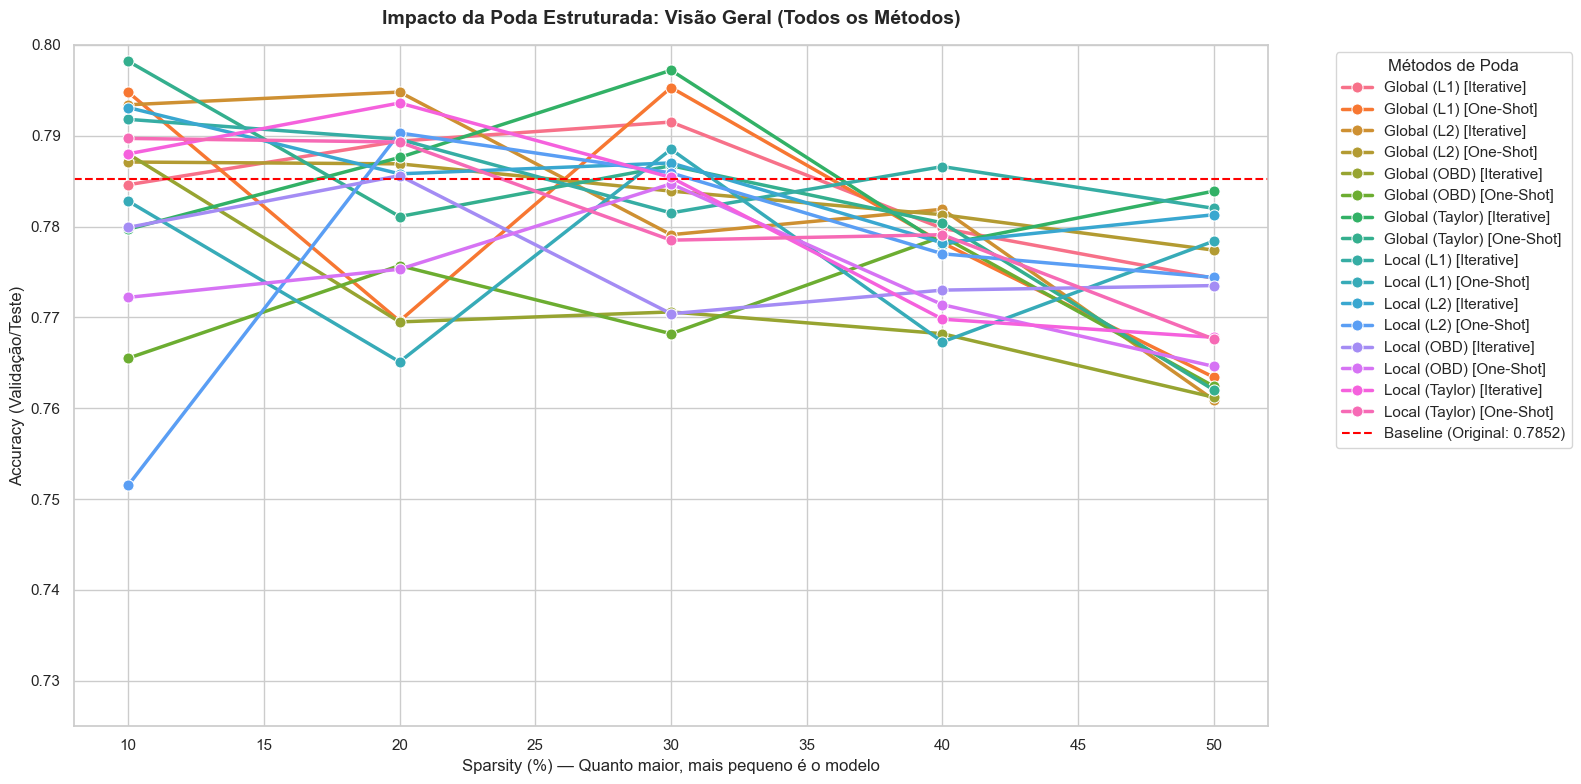


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)


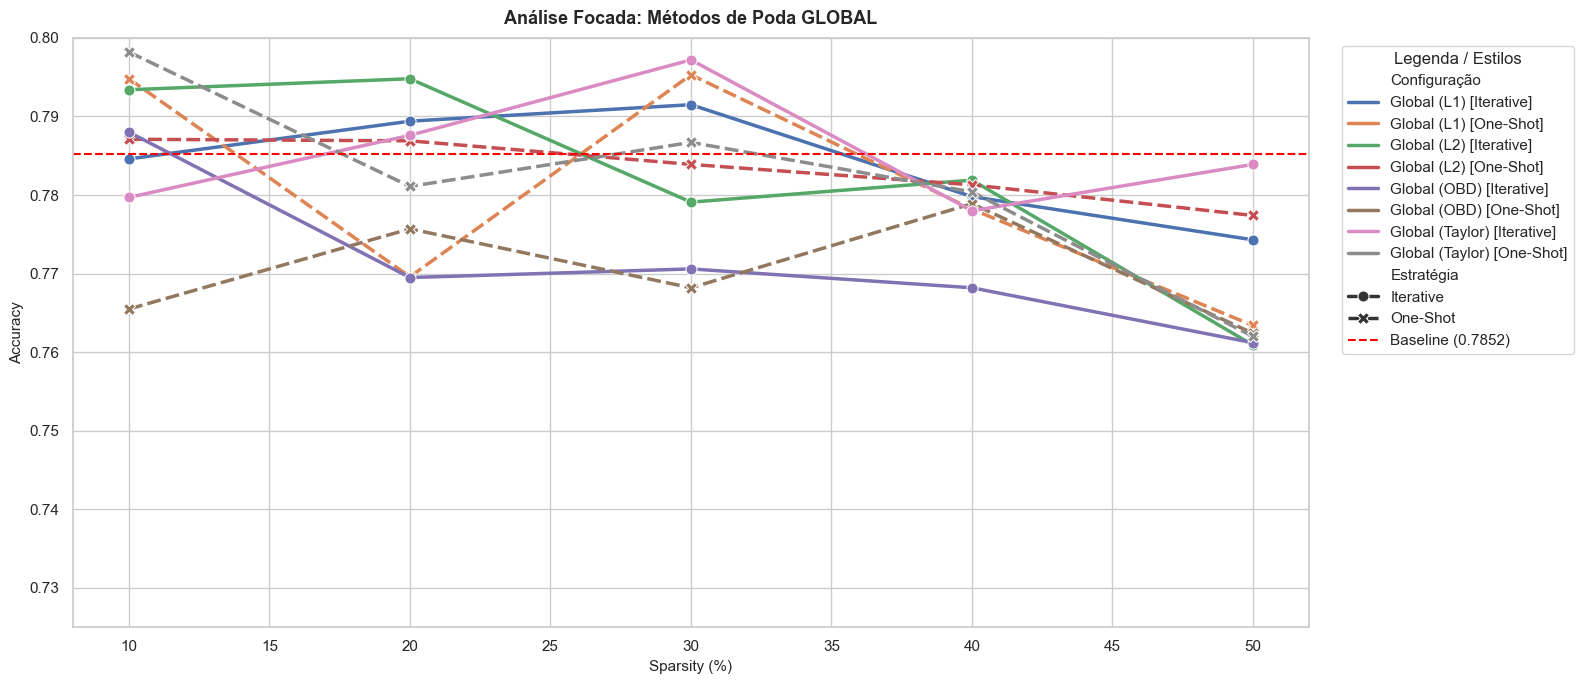

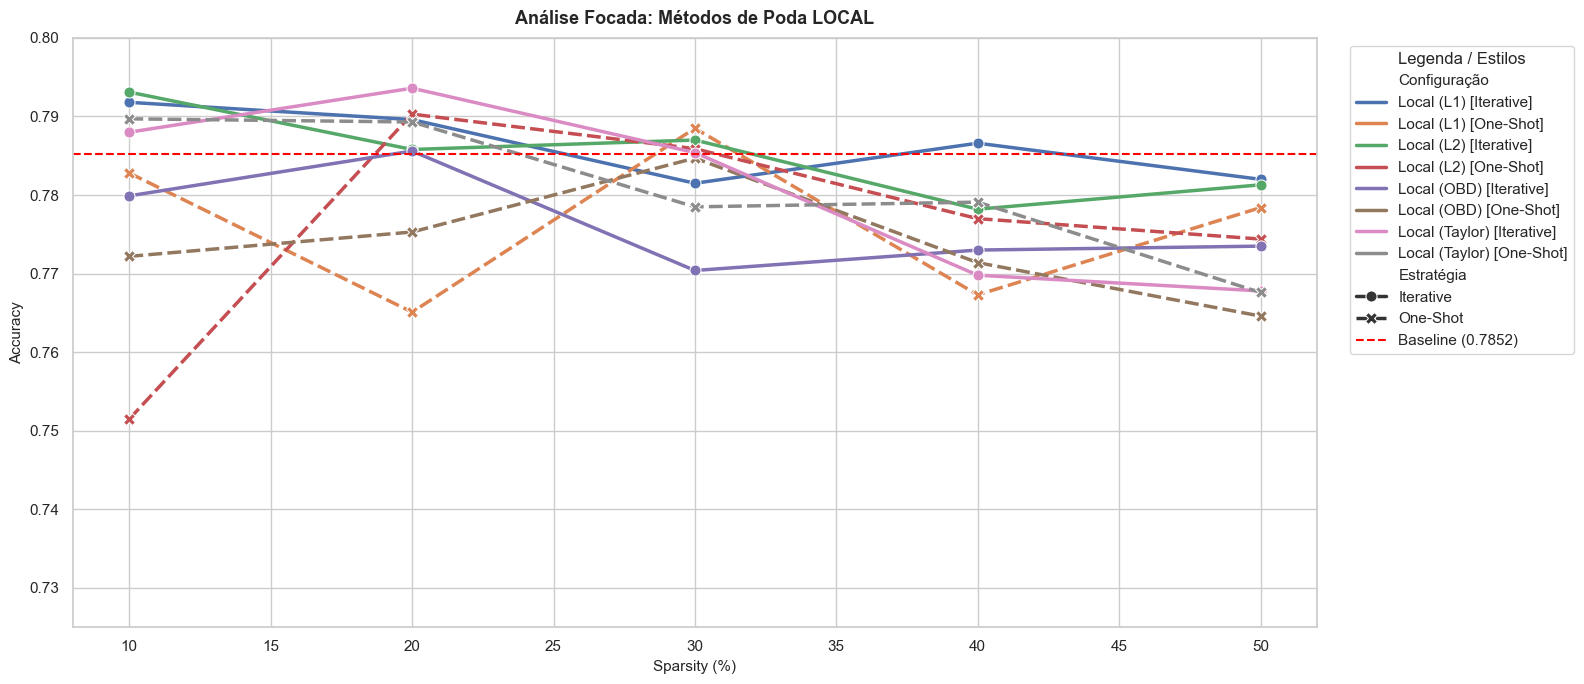

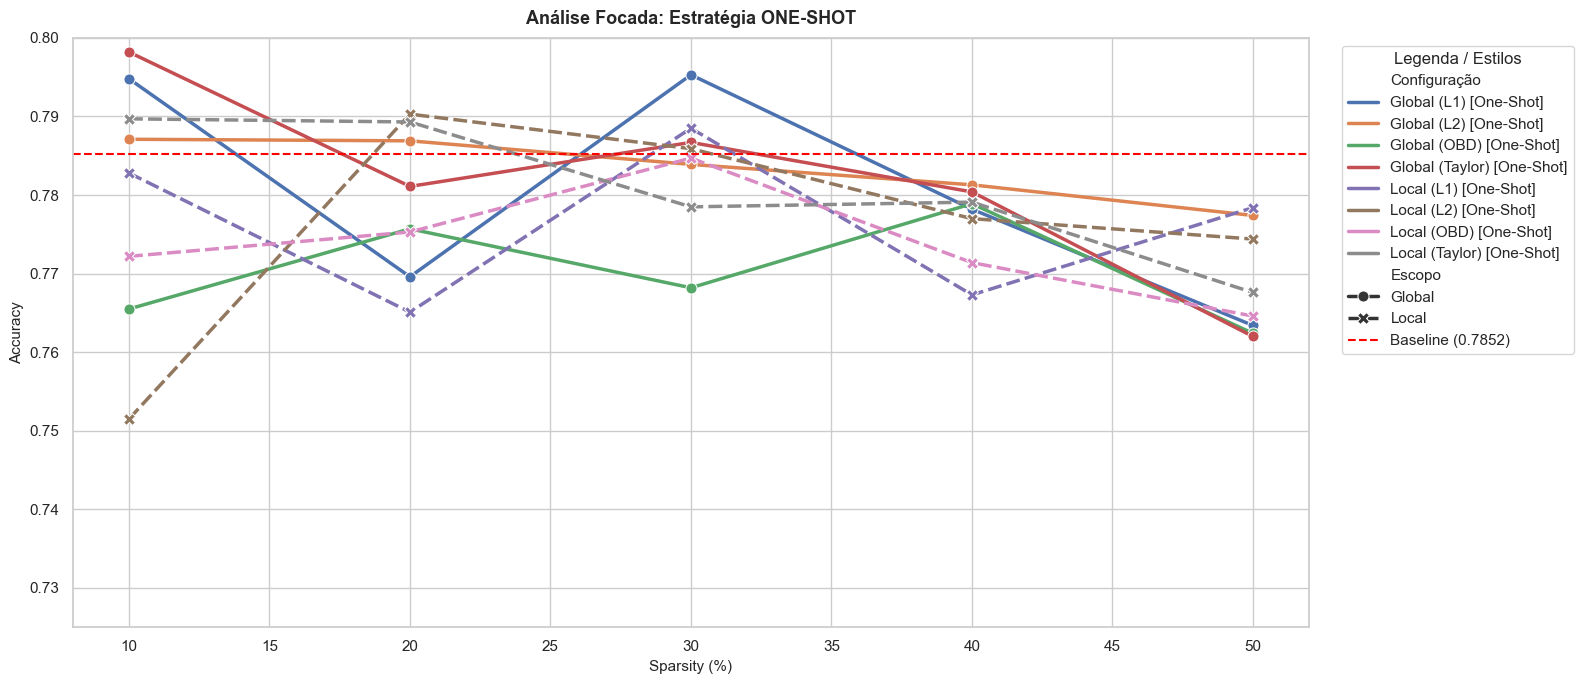

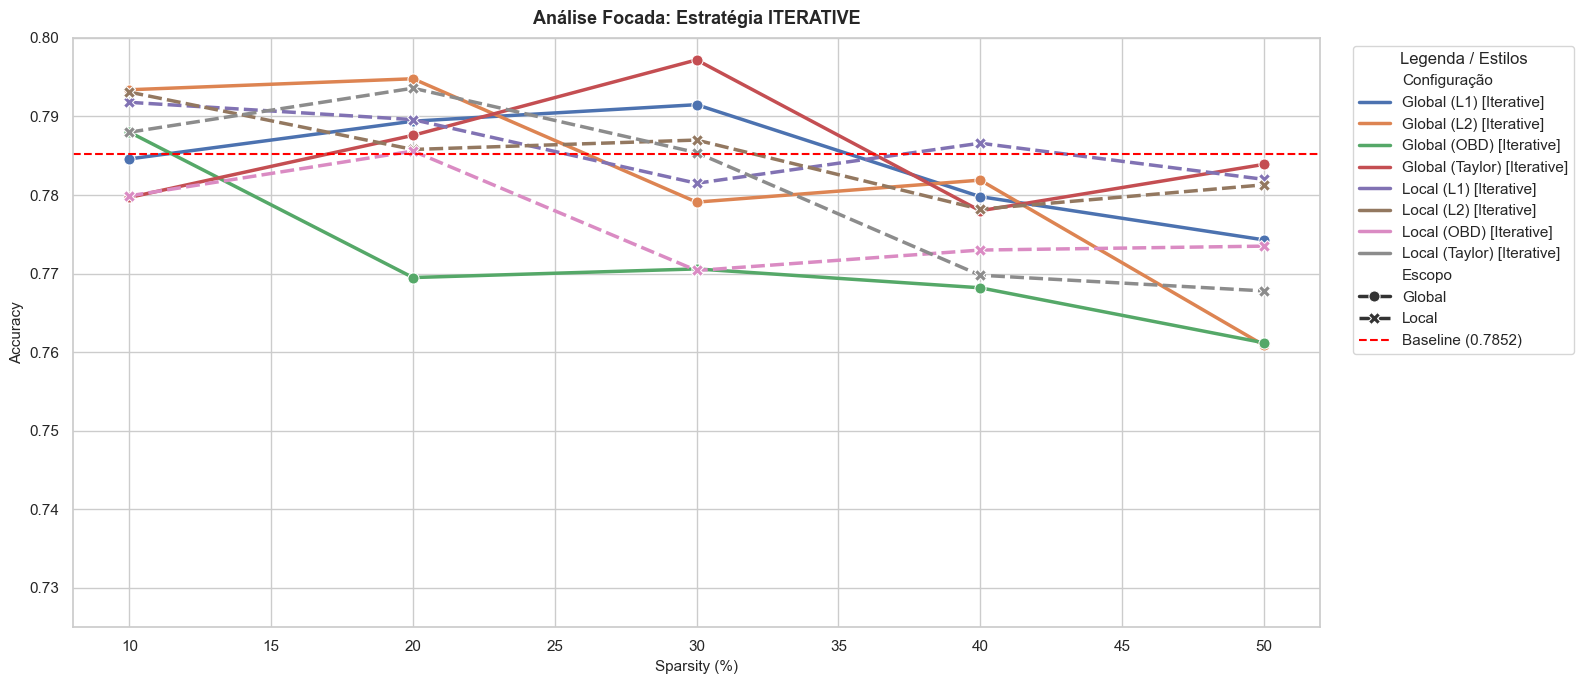

In [36]:
# 1. Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_vgg')
dados_grafico = []

# Guardar a precisão do baseline se existir
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name     # Ex: Global ou Local
        norma = model_path.parent.name             # Ex: L1, L2 ou Taylor
        stem = model_path.stem                     # Ex: VGG_one-shot_10pct
        
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            # Formatação para capitular os nomes e deixar a legenda bonita
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "Accuracy": post.get('accuracy', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# ==============================================================================
# GRÁFICO 1: VISÃO GERAL (TODOS OS MÉTODOS)
# ==============================================================================
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="Accuracy", 
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_acc:
    plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original: {baseline_acc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Todos os Métodos)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Accuracy (Validação/Teste)", fontsize=12)
plt.ylim(0.725, 0.80) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)
# ==============================================================================
# Adicionámos a chave "coluna_estilo" para ditar o que define o tipo de linha em cada gráfico
analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot",
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)\n{'='*80}")

for analise in analises_especificas:
    # Filtrar o dataframe para a categoria atual
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    # O truque está no parâmetro 'style' combinado com o 'hue'
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="Accuracy", 
        hue="Configuração", 
        style=analise["coluna_estilo"],  # <--- Aplica estilos de linha diferentes dinamicamente
        markers=True,                    # <--- Faz com que os marcadores também mudem de formato para ajudar daltónicos
        linewidth=2.5,
        markersize=8
    )
    
    # Linha de referência do Baseline
    if baseline_acc:
        plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_acc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Accuracy", fontsize=11)
    plt.ylim(0.725, 0.80) 
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

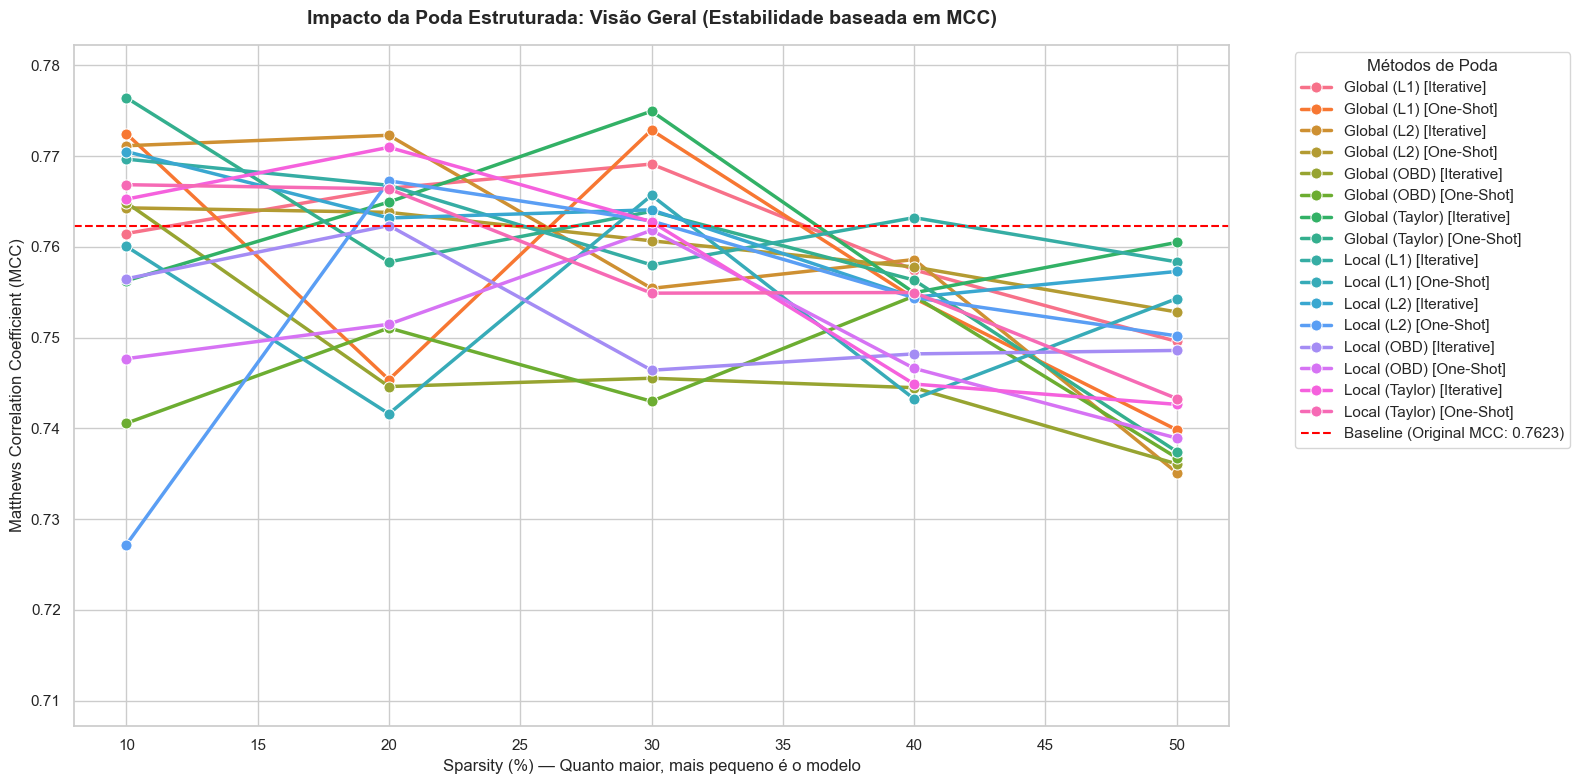


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)


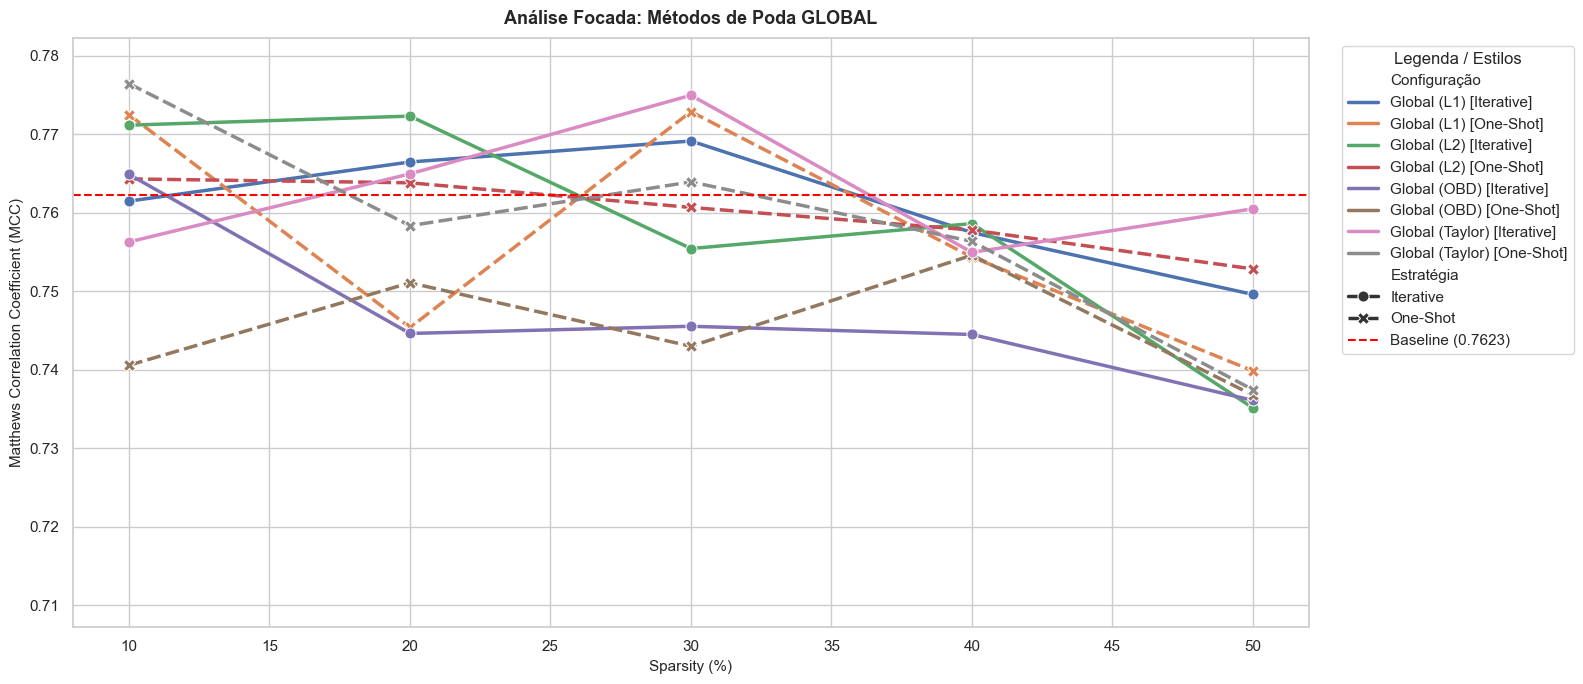

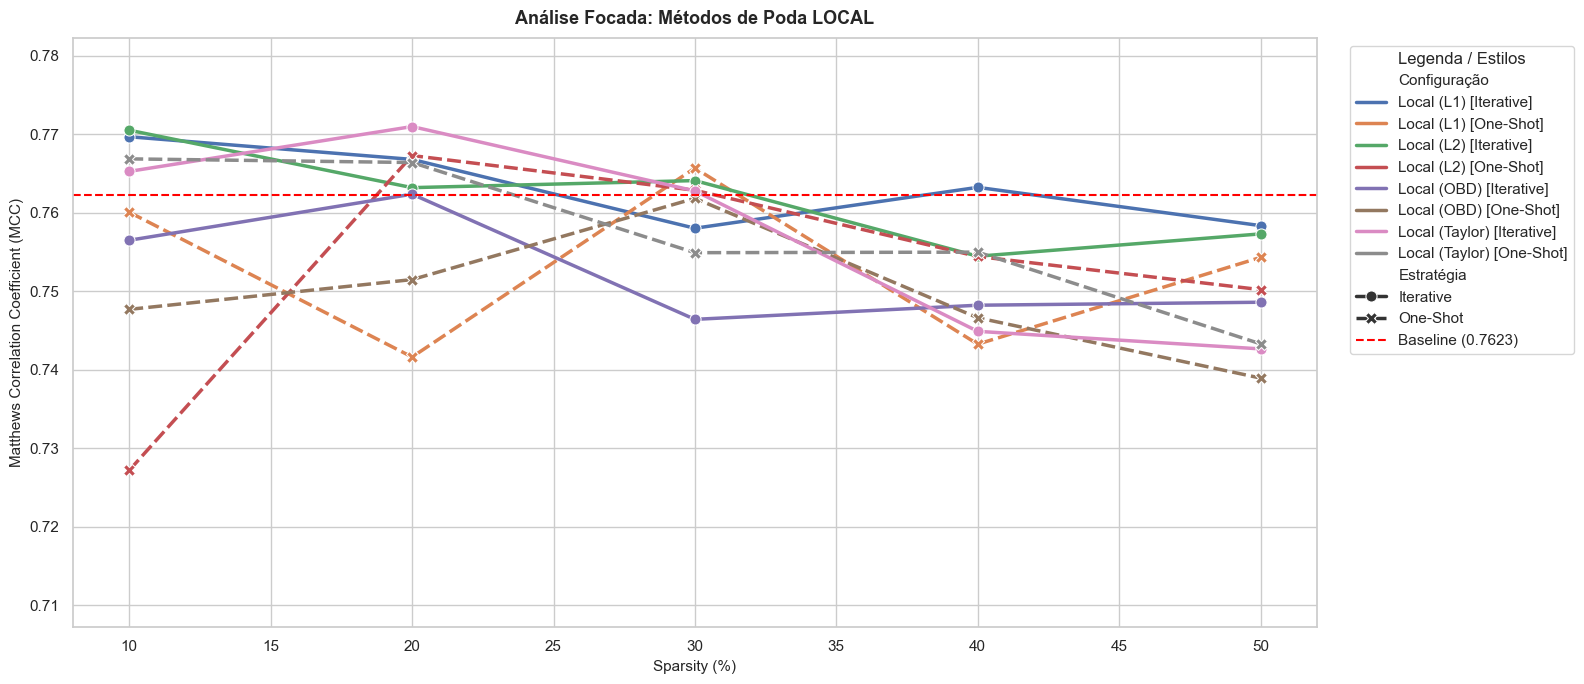

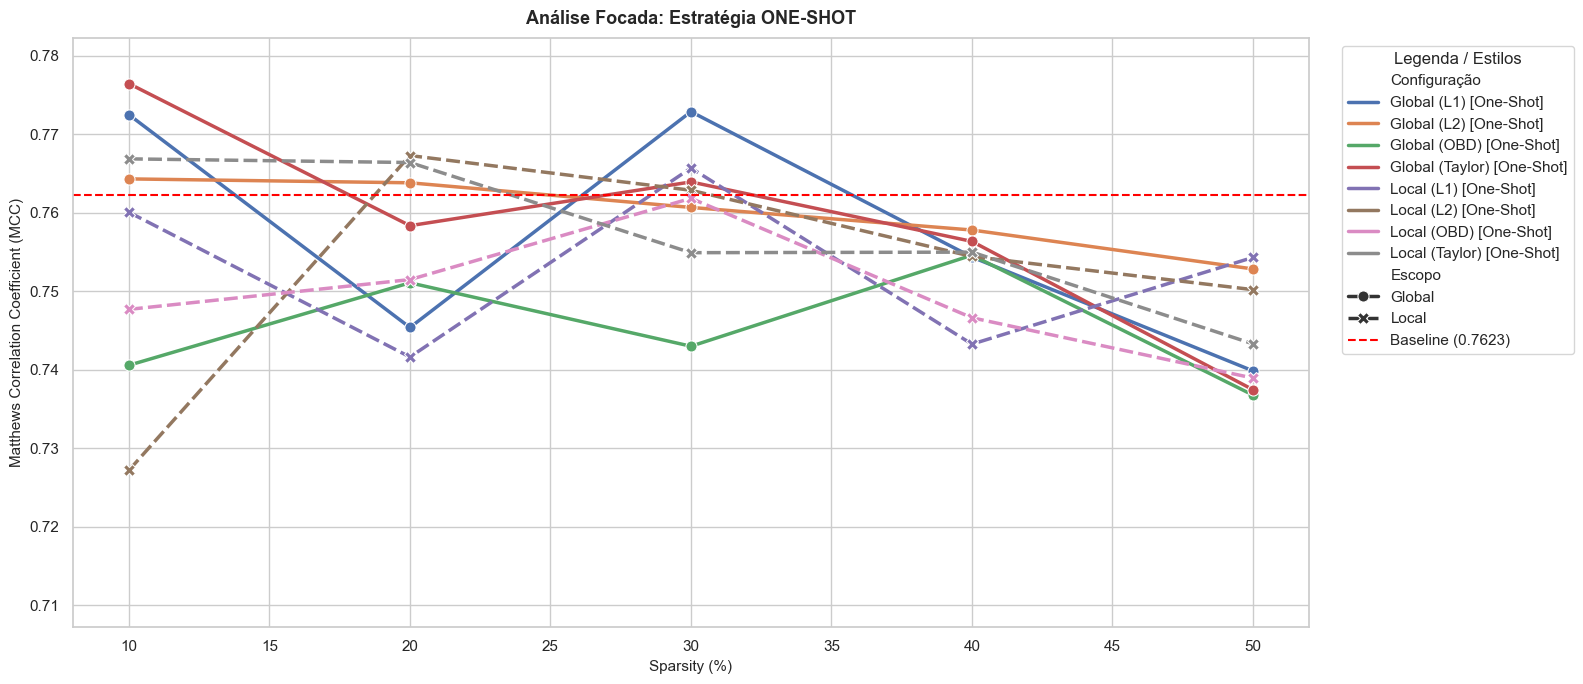

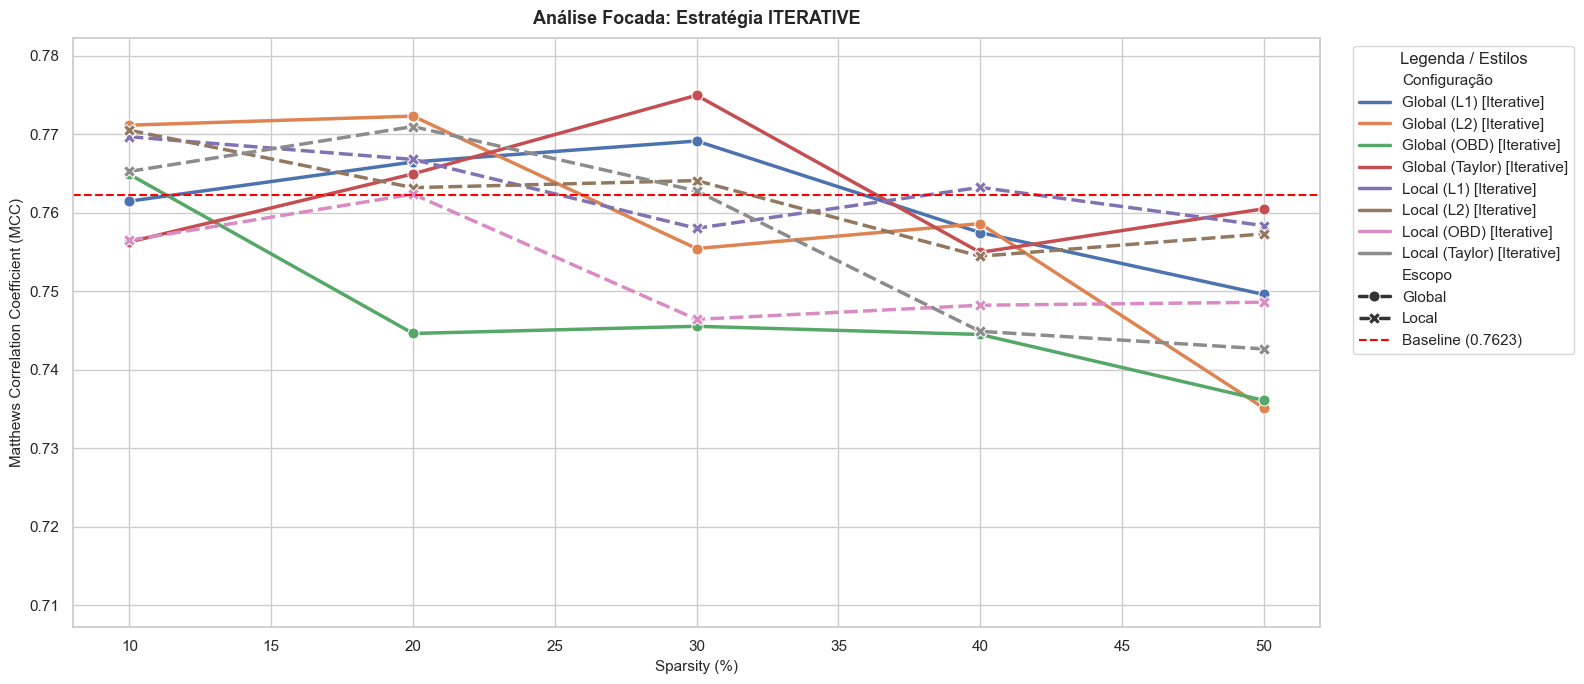

: 

In [ ]:
# 1. Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_vgg')
dados_grafico = []

# Guardar o MCC e a precisão do baseline se existirem
baseline_mcc = baseline_results.get('mcc', None) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

# Caso o dicionário do baseline use outra designação ou queiras extrair diretamente do df_resultados anterior:
if baseline_mcc is None and 'df_resultados' in locals():
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'MCC' in df_resultados.columns else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name
        norma = model_path.parent.name
        stem = model_path.stem
        
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            # Formatação para capitular os nomes e deixar a legenda bonita
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# Ajuste automático do limite inferior do gráfico com base nos dados reais de MCC
min_mcc_detectado = df_plot['MCC'].min() if not df_plot.empty else 0.60
# Define um patamar mínimo para o gráfico não achatar as curvas (usa o menor valor ou 0.65 por segurança)
limite_inferior_y = max(0.50, min_mcc_detectado - 0.02)
limite_superior_y = (baseline_mcc + 0.02) if baseline_mcc else 0.82

# ==============================================================================
# GRÁFICO 1: VISÃO GERAL (TODOS OS MÉTODOS)
# ==============================================================================
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="MCC",
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_mcc is not None:
    plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original MCC: {baseline_mcc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Estabilidade baseada em MCC)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=12)
plt.ylim(limite_inferior_y, limite_superior_y) 
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)
# ==============================================================================
analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot", 
        "coluna_estilo": "Escopo"      
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)\n{'='*80}")

for analise in analises_especificas:
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="MCC",
        hue="Configuração", 
        style=analise["coluna_estilo"],  
        markers=True,                    
        linewidth=2.5,
        markersize=8
    )
    
    if baseline_mcc is not None:
        plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_mcc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=11)
    plt.ylim(limite_inferior_y, limite_superior_y) 
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

In [ ]:
# ==============================================================================
# CONFIGURAÇÃO DE TOLERÂNCIA
# ==============================================================================
# Mantemos o filtro inicial pela Accuracy, mas expandimos a análise total
tolerancia_maxima_acc = 0.02

# Extração segura das métricas de referência do Baseline
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_acc = baseline_results.get('accuracy', 0)
    baseline_mcc = baseline_results.get('mcc', 0)
    baseline_kappa = baseline_results.get('cohen_kappa', 0)
else:
    baseline_acc = df_resultados[df_resultados['Método'] == 'Baseline']['Accuracy'].values[0] if 'df_resultados' in locals() else None
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'df_resultados' in locals() else 0
    baseline_kappa = df_resultados[df_resultados['Método'] == 'Baseline']['Cohen Kappa'].values[0] if 'df_resultados' in locals() else 0

if baseline_acc:
    limite_minimo_accuracy = baseline_acc - tolerancia_maxima_acc
    
    # 1. Filtrar os modelos que passam no teste de estabilidade de Accuracy
    df_filtrado = df_resultados[df_resultados['Accuracy'] >= limite_minimo_accuracy].copy()
    
    # 2. Remover a linha do Baseline para podermos avaliar apenas o ranking dos podados
    df_filtrado = df_filtrado[df_filtrado['Método'] != 'Baseline']
    
    # 3. Ordenar do mais comprimido (mais leve) para o menos comprimido
    df_filtrado = df_filtrado.sort_values(by="Compressão (x)", ascending=False)
    
    print(f"=======================================================================")
    print(f"   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -{tolerancia_maxima_acc*100}%)")
    print(f"=======================================================================")
    print(f" [Métricas de Referência do Baseline Original]")
    print(f"  -> Accuracy: {baseline_acc:.4f}  |  MCC: {baseline_mcc:.4f}  |  Cohen's Kappa: {baseline_kappa:.4f}\n")
    
    if not df_filtrado.empty:
        # Colunas selecionadas a dedo para o teu relatório final (focado em compressão + robustez)
        colunas_relatorio = [
            "Método", "Sparsity (%)", "Compressão (x)", 
            "Accuracy", "MCC", "Cohen Kappa", 
            "Latência (s)", "VRAM (MB)"
        ]
        
        # Selecionar os top 5 modelos mais leves que não quebraram a performance
        df_top = df_filtrado[colunas_relatorio].head(10)
        
        # Aplicar um estilo visual para realçar os campeões de robustez
        estilo_executivo = df_top.style.set_properties(**{'text-align': 'center'}) \
            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
            .highlight_max(subset=['MCC', 'Cohen Kappa', 'Compressão (x)'], color='lightgreen') \
            .highlight_min(subset=['Latência (s)'], color='lightcyan') \
            .format({
                "Accuracy": "{:.4f}",
                "MCC": "{:.4f}",
                "Cohen Kappa": "{:.4f}",
                "Latência (s)": "{:.4f}",
                "Compressão (x)": "{:.2f}x"
            })
        
        display(estilo_executivo)
        
        # Pequeno aviso analítico no terminal para te ajudar a decidir
        melhor_mcc_idx = df_top['MCC'].idxmax()
        print(f"Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o \n"
              f"'{df_top.loc[melhor_mcc_idx, 'Método']}' com MCC de {df_top.loc[melhor_mcc_idx, 'MCC']:.4f} "
              f"e uma compressão de {df_top.loc[melhor_mcc_idx, 'Compressão (x)']:.2f}x.")
        
    else:
        print("Nenhum modelo podado conseguiu ficar dentro da tolerância exigida.")
else:
    print("Erro: Não foi possível determinar o 'baseline_acc' para aplicar o filtro.")

   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -2.0%)
 [Métricas de Referência do Baseline Original]
  -> Accuracy: 0.7852  |  MCC: 0.7623  |  Cohen's Kappa: 0.7613



,Método,Sparsity (%),Compressão (x),Accuracy,MCC,Cohen Kappa,Latência (s),VRAM (MB)
20,Global L2 (Magnitude) (one-shot),50,4.18x,0.7774,0.7528,0.7527,8.2419,3634.490000
65,Local OBD (Magnitude) (iterative),50,4.03x,0.7735,0.7486,0.7483,7.8651,935.860000
55,Local L2 (Magnitude) (iterative),50,4.03x,0.7813,0.7573,0.7570,8.2234,1268.450000
45,Local L1 (Magnitude) (iterative),50,4.03x,0.7820,0.7583,0.7578,7.7100,463.600000
75,Local Taylor (Gradiente) (iterative),50,4.03x,0.7678,0.7426,0.7420,7.9423,2415.590000
80,Local Taylor (Gradiente) (one-shot),50,3.99x,0.7676,0.7433,0.7418,8.0852,1767.300000
50,Local L1 (Magnitude) (one-shot),50,3.99x,0.7784,0.7543,0.7538,7.8315,485.460000
60,Local L2 (Magnitude) (one-shot),50,3.99x,0.7744,0.7502,0.7493,9.0321,758.430000
5,Global L1 (Magnitude) (iterative),50,3.85x,0.7743,0.7496,0.7492,8.1531,3279.390000
35,Global Taylor (Gradiente) (iterative),50,3.19x,0.7839,0.7605,0.7599,9.0944,1476.940000


Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o 
'Global Taylor (Gradiente) (iterative)' com MCC de 0.7605 e uma compressão de 3.19x.


: 

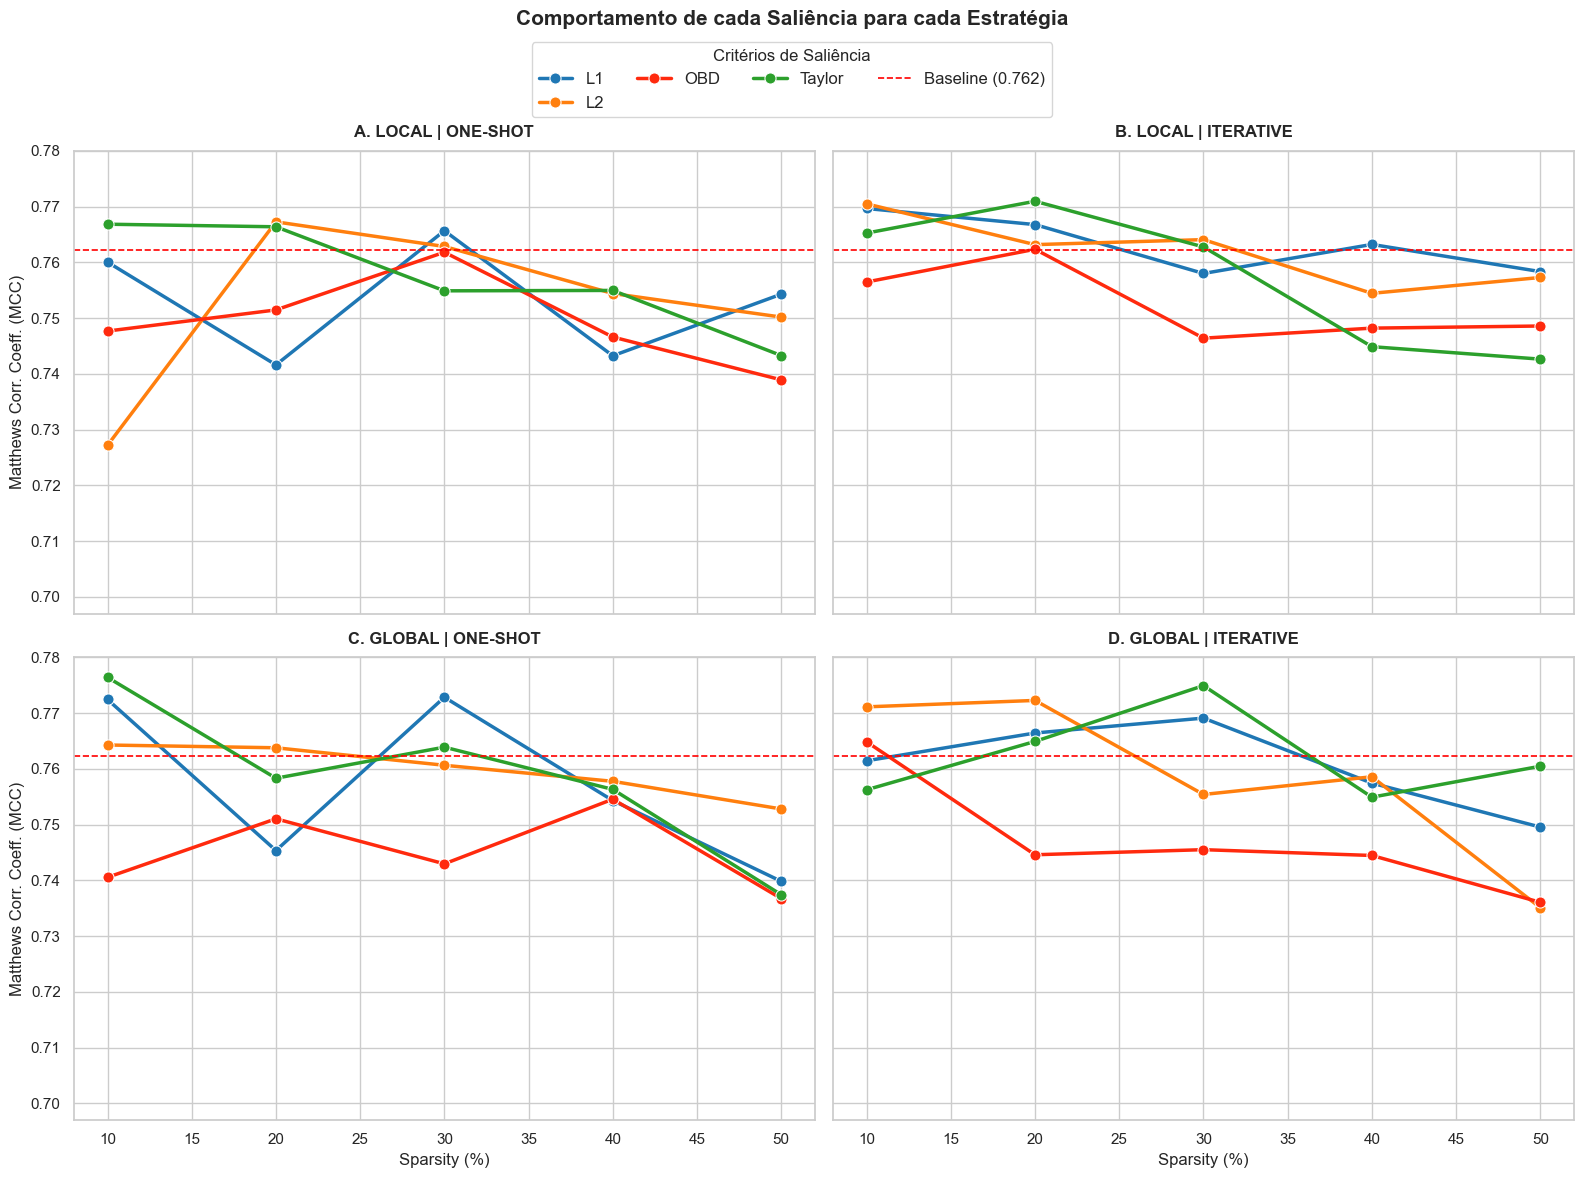

: 

In [ ]:
# 1. Recolha detalhada dos dados (incluindo explicitamente a Saliência)
save_dir = Path('modelos_podados_vgg')
dados_analise = []

# Extrair referências do Baseline
baseline_mcc = baseline_results.get('mcc', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        ambito = model_path.parent.parent.name     # Global / Local
        norma = model_path.parent.name             # L1 / L2 / Taylor
        stem = model_path.stem                     # VGG_one-shot_10pct
        
        match = re.match(r"VGG_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # one-shot / iterative
            sparsity_pct = int(match.group(2))
            
            dados_analise.append({
                "Ambito": ambito,
                "Saliência": norma,                 # L1, L2 ou Taylor
                "Estratégia": estrategia.lower(),   # one-shot ou iterative
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Accuracy": post.get('accuracy', 0)
            })
    except Exception:
        continue

df_saliencia = pd.DataFrame(dados_analise)

# ==============================================================================
# CONSTRUÇÃO DA MATRIZ DE GRÁFICOS 2x2
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
sns.set_theme(style="whitegrid")

# Definição dos quadrantes: (Linha, Coluna) -> (Ambito, Estratégia)
quadrantes = [
    {"ambito": "Local",  "estrategia": "one-shot",  "ax": axes[0, 0], "titulo": "A. LOCAL | ONE-SHOT"},
    {"ambito": "Local",  "estrategia": "iterative", "ax": axes[0, 1], "titulo": "B. LOCAL | ITERATIVE"},
    {"ambito": "Global", "estrategia": "one-shot",  "ax": axes[1, 0], "titulo": "C. GLOBAL | ONE-SHOT"},
    {"ambito": "Global", "estrategia": "iterative", "ax": axes[1, 1], "titulo": "D. GLOBAL | ITERATIVE"}
]

# Palete de cores fixa para garantir que L1, L2 e Taylor mantêm a mesma cor em todos os gráficos
cores_saliencia = {"L1": "#1f77b4", "L2": "#ff7f0e", "Taylor": "#2ca02c", "OBD": "#ff2a0e"}

for q in quadrantes:
    ax = q["ax"]
    # Filtrar dados para este cenário específico
    df_sub = df_saliencia[
        (df_saliencia["Ambito"].str.lower() == q["ambito"].lower()) & 
        (df_saliencia["Estratégia"] == q["estrategia"])
    ]
    
    if not df_sub.empty:
        # Desenhar as curvas de saliência para este quadrante
        sns.lineplot(
            data=df_sub,
            x="Sparsity (%)",
            y="MCC",
            hue="Saliência",
            palette=cores_saliencia,
            marker="o",
            linewidth=2.5,
            markersize=8,
            ax=ax
        )
    else:
        ax.text(0.5, 0.5, "Sem dados para esta combinação", ha='center', va='center', fontsize=12, color='gray')

    # Linha horizontal do Baseline (A nossa meta perfeita)
    if baseline_mcc is not None:
        ax.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_mcc:.3f})')
    
    ax.set_title(q["titulo"], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Sparsity (%)" if ax in axes[1] else "")
    ax.set_ylabel("Matthews Corr. Coeff. (MCC)" if ax in [axes[0, 0], axes[1, 0]] else "")
    ax.set_ylim(0.697, 0.78)
    ax.legend().remove()     # Remove a legenda individual para criar uma unificada limpa

# Criar uma legenda única e elegante para o topo do gráfico
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=4, fontsize=12, title="Critérios de Saliência")

plt.suptitle("Comportamento de cada Saliência para cada Estratégia", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### Análise Multiobjetivo com Fronteiras de Pareto

A optimização de modelos comprimidos envolve objectivos frequentemente contraditórios:

- Maximizar accuracy
- Minimizar latência
- Reduzir número de parâmetros

Para identificar as melhores soluções de compromisso é utilizada uma **análise de Pareto**, que permite destacar configurações não dominadas.

Uma solução é considerada **Pareto-ótima** quando não é possível melhorar uma métrica sem degradar outra.

In [ ]:
def compute_pareto_front(df, maximize_metrics=None, minimize_metrics=None,):
    """
    Calcula soluções Pareto-ótimas.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com resultados.

    maximize_metrics : list[str]
        Métricas a maximizar.

    minimize_metrics : list[str]
        Métricas a minimizar.

    Returns
    -------
    pd.DataFrame
        Apenas soluções Pareto-ótimas.
    """
    maximize_metrics = maximize_metrics or []
    minimize_metrics = minimize_metrics or []
    metric_cols = maximize_metrics + minimize_metrics

    temp = df[metric_cols].copy()

    # converter maximização -> minimização
    for col in maximize_metrics:
        temp[col] = -temp[col]

    values = temp.to_numpy()
    is_pareto = np.ones(len(values), dtype=bool)

    for i, candidate in enumerate(values):
        if not is_pareto[i]:
            continue

        dominated = np.all(candidate <= values, axis=1) & \
                    np.any(candidate < values, axis=1)
        dominated[i] = False
        is_pareto[dominated] = False

    return df[is_pareto].copy()


def plot_pareto_front(df, x_metric="Parâmetros", y_metric="Accuracy", color_metric="MCC", maximize_metrics=None, 
                      minimize_metrics=None, label_column="Método", title="Pareto Front"):
    """
    Plot da Pareto Front.
    """
    if maximize_metrics is None:
        maximize_metrics = [y_metric, color_metric]

    if minimize_metrics is None:
        minimize_metrics = [x_metric]

    pareto_df = compute_pareto_front(
        df=df,
        maximize_metrics=maximize_metrics,
        minimize_metrics=minimize_metrics
    )

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        df[x_metric],
        df[y_metric],
        c=df[color_metric],
        s=120,
        alpha=0.7
    )
    # destacar Pareto front
    plt.scatter(
        pareto_df[x_metric],
        pareto_df[y_metric],
        s=280,
        marker="*"
    )
    # labels
    for _, row in pareto_df.iterrows():

        label = (f"{row[label_column]}"f"\n({int(row['Sparsity (%)']*100)}%)")
        plt.annotate(label,(row[x_metric], row[y_metric]),fontsize=8)

    plt.xlabel(x_metric)
    plt.ylabel(y_metric)
    plt.title(title)

    plt.colorbar(scatter,label=color_metric)

    plt.grid(True)
    plt.show()

    return pareto_df

: 

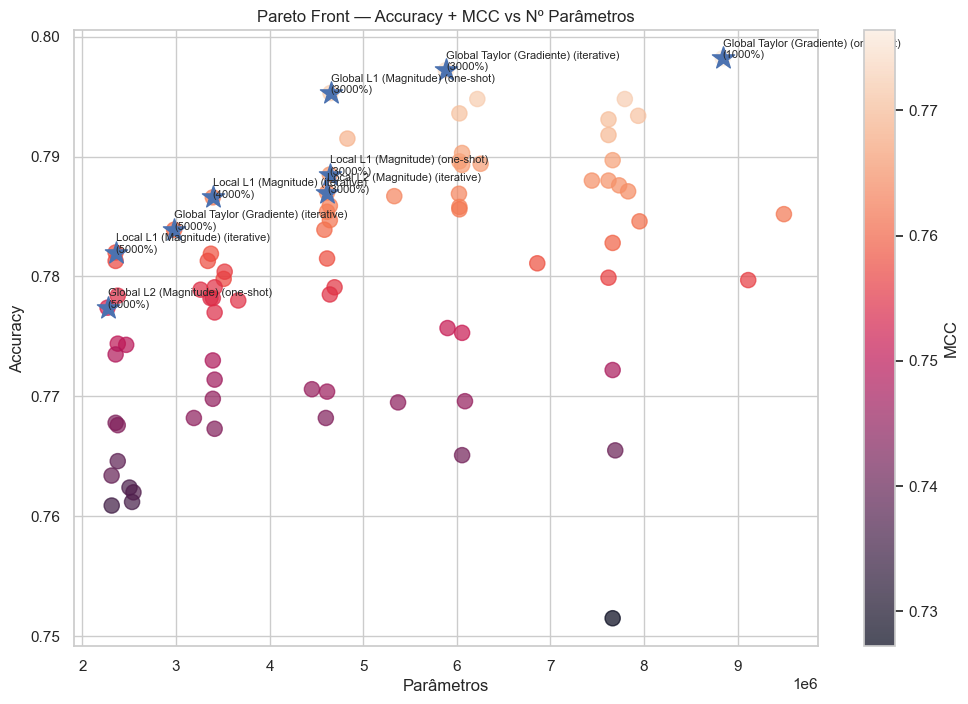

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
8,Global L1 (Magnitude) (one-shot),30,4650268,2.04,0.7953,0.8936,0.7953,0.7965,0.7965,0.7953,0.7953,0.7946,0.7946,0.7726,0.7729,8.1320,2705.42
20,Global L2 (Magnitude) (one-shot),50,2268649,4.18,0.7774,0.9313,0.7774,0.7799,0.7799,0.7774,0.7774,0.7779,0.7779,0.7527,0.7528,8.2419,3634.49
33,Global Taylor (Gradiente) (iterative),30,5882743,1.61,0.7972,0.9510,0.7972,0.7966,0.7966,0.7972,0.7972,0.7956,0.7956,0.7747,0.7749,8.9629,1430.05
35,Global Taylor (Gradiente) (iterative),50,2979784,3.19,0.7839,1.0308,0.7839,0.7889,0.7889,0.7839,0.7839,0.7837,0.7837,0.7599,0.7605,9.0944,1476.94
36,Global Taylor (Gradiente) (one-shot),10,8840559,1.07,0.7982,0.9123,0.7982,0.8008,0.8008,0.7982,0.7982,0.7967,0.7967,0.7758,0.7764,8.2434,465.70
44,Local L1 (Magnitude) (iterative),40,3393115,2.80,0.7866,0.9973,0.7866,0.7878,0.7878,0.7866,0.7866,0.7855,0.7855,0.7629,0.7632,8.0914,355.12
45,Local L1 (Magnitude) (iterative),50,2354668,4.03,0.7820,0.9920,0.7820,0.7846,0.7846,0.7820,0.7820,0.7807,0.7807,0.7578,0.7583,7.7100,463.60
48,Local L1 (Magnitude) (one-shot),30,4643227,2.04,0.7885,0.9328,0.7885,0.7915,0.7915,0.7885,0.7885,0.7866,0.7866,0.7650,0.7657,7.8667,435.08
53,Local L2 (Magnitude) (iterative),30,4613509,2.06,0.7870,1.0090,0.7870,0.7965,0.7965,0.7870,0.7870,0.7886,0.7886,0.7633,0.7641,8.2105,1222.06


: 

In [ ]:
pareto_acc_mcc = plot_pareto_front(
    df=df_resultados,
    x_metric="Parâmetros",
    y_metric="Accuracy",
    color_metric="MCC",
    maximize_metrics=["Accuracy", "MCC"],
    minimize_metrics=["Parâmetros"],
    label_column="Método",
    title="Pareto Front — Accuracy + MCC vs Nº Parâmetros"
)

pareto_acc_mcc

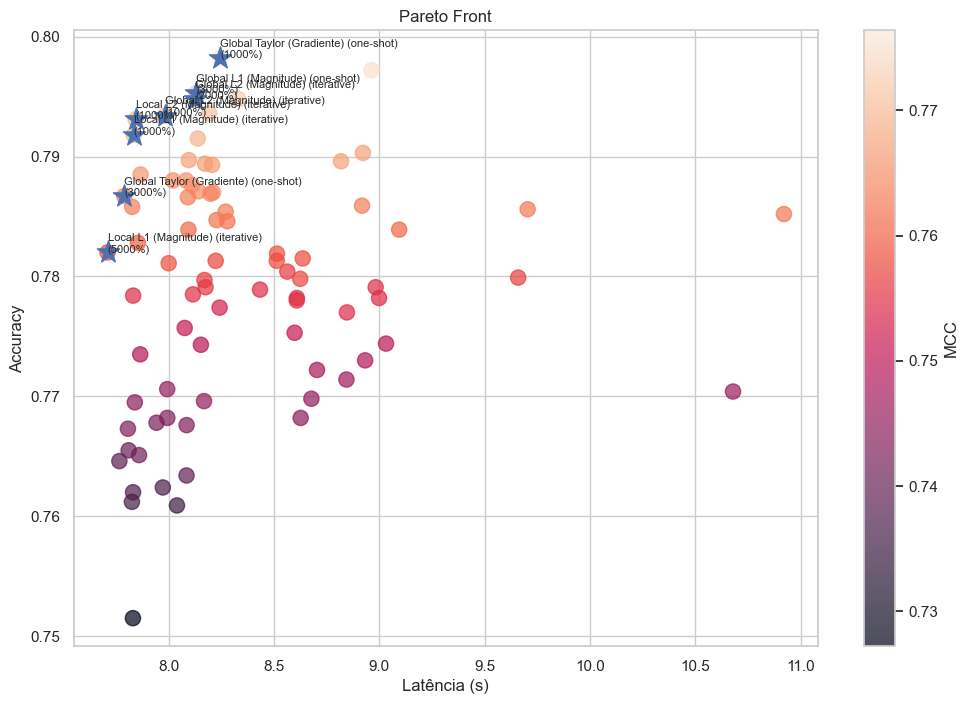

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
8,Global L1 (Magnitude) (one-shot),30,4650268,2.04,0.7953,0.8936,0.7953,0.7965,0.7965,0.7953,0.7953,0.7946,0.7946,0.7726,0.7729,8.1320,2705.42
11,Global L2 (Magnitude) (iterative),10,7936728,1.20,0.7934,1.0255,0.7934,0.7973,0.7973,0.7934,0.7934,0.7921,0.7921,0.7704,0.7711,7.9819,3930.03
12,Global L2 (Magnitude) (iterative),20,6218659,1.53,0.7948,0.9709,0.7948,0.7970,0.7970,0.7948,0.7948,0.7945,0.7945,0.7720,0.7723,8.1253,4028.58
36,Global Taylor (Gradiente) (one-shot),10,8840559,1.07,0.7982,0.9123,0.7982,0.8008,0.8008,0.7982,0.7982,0.7967,0.7967,0.7758,0.7764,8.2434,465.70
38,Global Taylor (Gradiente) (one-shot),30,5331439,1.78,0.7867,0.9534,0.7867,0.7942,0.7942,0.7867,0.7867,0.7862,0.7862,0.7630,0.7639,7.7889,705.87
41,Local L1 (Magnitude) (iterative),10,7619794,1.25,0.7918,1.0958,0.7918,0.7976,0.7976,0.7918,0.7918,0.7900,0.7900,0.7687,0.7697,7.8337,735.50
45,Local L1 (Magnitude) (iterative),50,2354668,4.03,0.7820,0.9920,0.7820,0.7846,0.7846,0.7820,0.7820,0.7807,0.7807,0.7578,0.7583,7.7100,463.60
51,Local L2 (Magnitude) (iterative),10,7619794,1.25,0.7931,1.0205,0.7931,0.8008,0.8008,0.7931,0.7931,0.7955,0.7955,0.7701,0.7705,7.8432,1047.08


: 

In [ ]:
pareto_lat_acc = plot_pareto_front(
    df_resultados,

    x_metric="Latência (s)",
    y_metric="Accuracy",
    color_metric="MCC",

    maximize_metrics=[
        "Accuracy",
        "MCC"
    ],

    minimize_metrics=[
        "Latência (s)"
    ]
)
pareto_lat_acc

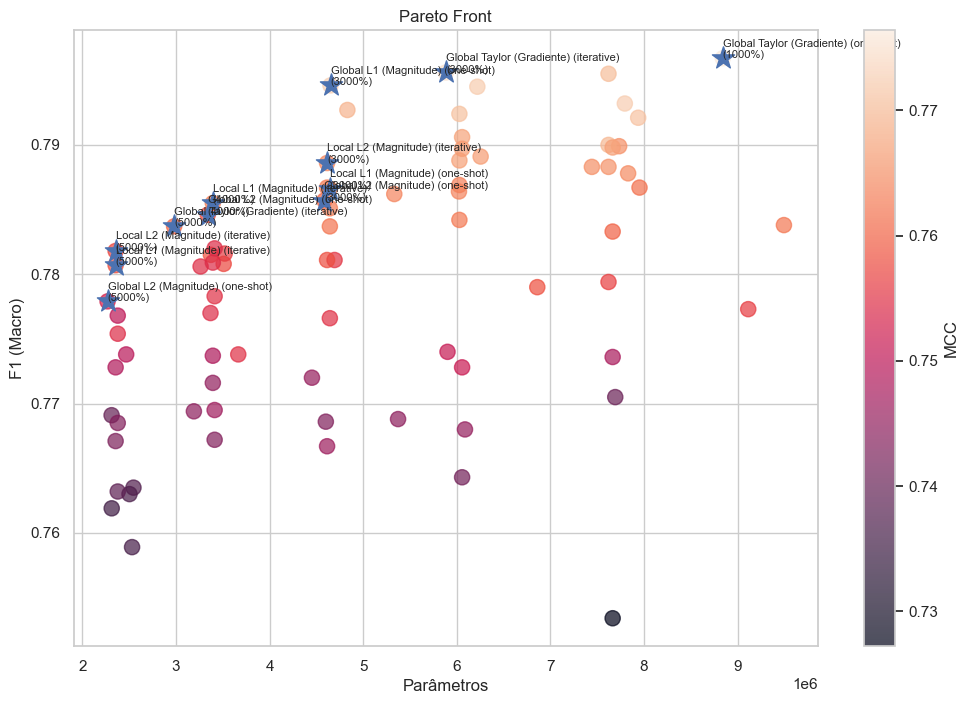

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
8,Global L1 (Magnitude) (one-shot),30,4650268,2.04,0.7953,0.8936,0.7953,0.7965,0.7965,0.7953,0.7953,0.7946,0.7946,0.7726,0.7729,8.1320,2705.42
18,Global L2 (Magnitude) (one-shot),30,4584913,2.07,0.7839,1.0023,0.7839,0.7940,0.7940,0.7839,0.7839,0.7857,0.7857,0.7599,0.7607,8.0941,3578.20
19,Global L2 (Magnitude) (one-shot),40,3339589,2.84,0.7813,1.0141,0.7813,0.7935,0.7935,0.7813,0.7813,0.7846,0.7846,0.7570,0.7578,8.5134,999.42
20,Global L2 (Magnitude) (one-shot),50,2268649,4.18,0.7774,0.9313,0.7774,0.7799,0.7799,0.7774,0.7774,0.7779,0.7779,0.7527,0.7528,8.2419,3634.49
33,Global Taylor (Gradiente) (iterative),30,5882743,1.61,0.7972,0.9510,0.7972,0.7966,0.7966,0.7972,0.7972,0.7956,0.7956,0.7747,0.7749,8.9629,1430.05
35,Global Taylor (Gradiente) (iterative),50,2979784,3.19,0.7839,1.0308,0.7839,0.7889,0.7889,0.7839,0.7839,0.7837,0.7837,0.7599,0.7605,9.0944,1476.94
36,Global Taylor (Gradiente) (one-shot),10,8840559,1.07,0.7982,0.9123,0.7982,0.8008,0.8008,0.7982,0.7982,0.7967,0.7967,0.7758,0.7764,8.2434,465.70
44,Local L1 (Magnitude) (iterative),40,3393115,2.80,0.7866,0.9973,0.7866,0.7878,0.7878,0.7866,0.7866,0.7855,0.7855,0.7629,0.7632,8.0914,355.12
45,Local L1 (Magnitude) (iterative),50,2354668,4.03,0.7820,0.9920,0.7820,0.7846,0.7846,0.7820,0.7820,0.7807,0.7807,0.7578,0.7583,7.7100,463.60
48,Local L1 (Magnitude) (one-shot),30,4643227,2.04,0.7885,0.9328,0.7885,0.7915,0.7915,0.7885,0.7885,0.7866,0.7866,0.7650,0.7657,7.8667,435.08


: 

In [ ]:
pareto_param_f1 = plot_pareto_front(
    df_resultados,

    x_metric="Parâmetros",
    y_metric="F1 (Macro)",
    color_metric="MCC",

    maximize_metrics=[
        "F1 (Macro)",
        "MCC"
    ],

    minimize_metrics=[
        "Parâmetros"
    ]
)
pareto_param_f1

   RANKING COMPLETO DOS INDIVÍDUOS NAS FRENTES DE PARETO (PRESERVANDO ÍNDICES E VALORES ORIGINAIS)
 Índice Original                                Método  Sparsity (%) Escopo (Global/Local) Saliência Estratégia de Poda  Frequência (Nº de Frentes)  Parâmetros  Compressão (x)  Accuracy   Loss  Bal. Acc  Prec (Macro)  Prec (Weighted)  Rec (Macro)  Rec (Weighted)  F1 (Macro)  F1 (Weighted)  Cohen Kappa    MCC  Latência (s)  VRAM (MB)
               8      Global L1 (Magnitude) (one-shot)            30                Global        L1           one-shot                           3     4650268            2.04    0.7953 0.8936    0.7953        0.7965           0.7965       0.7953          0.7953      0.7946         0.7946       0.7726 0.7729        8.1320    2705.42
              45      Local L1 (Magnitude) (iterative)            50                 Local        L1          iterative                           3     2354668            4.03    0.7820 0.9920    0.7820        0.7846           0.78

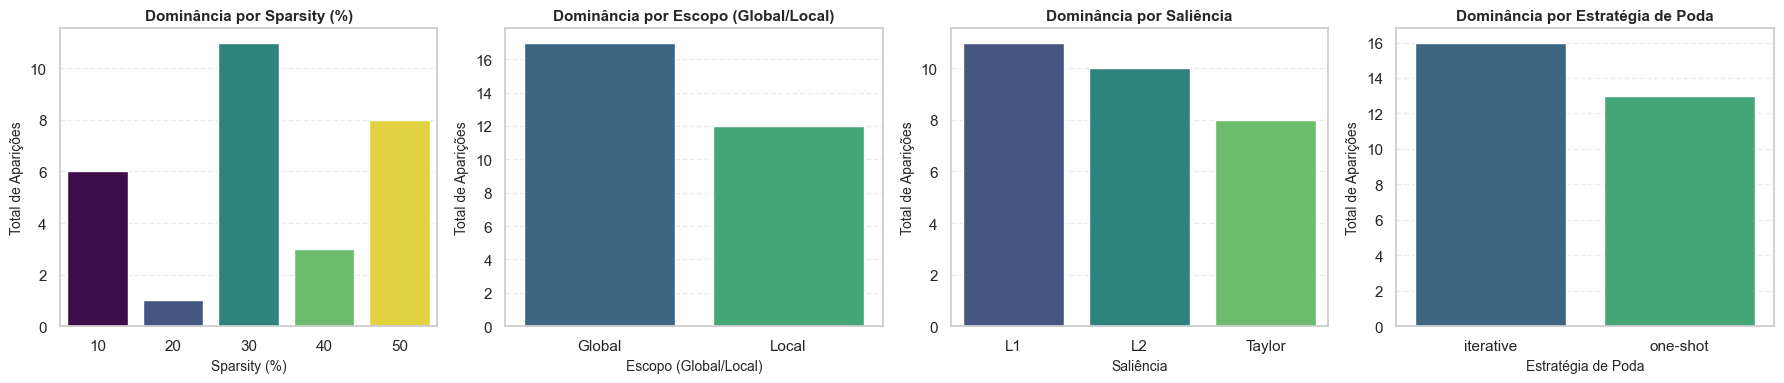

: 

In [ ]:
frentes_pareto = {
    "Acc vs MCC": pareto_acc_mcc if 'pareto_acc_mcc' in locals() else None,
    "Lat vs Acc": pareto_lat_acc if 'paretto_lat_acc' in locals() else None,
    "Param vs F1": pareto_param_f1 if 'paretto_param_f1' in locals() else None
}

df_acumulado = []

for nome_frente, df in frentes_pareto.items():
    if df is not None:
        df_temp = df.copy()
        # Reter o índice numérico original que aponta diretamente para o teu df_resultados
        df_temp['Índice Original'] = df_temp.index
        df_temp['Frente de Pareto'] = nome_frente
        
        # Extrair e isolar os hiperparâmetros codificados na coluna 'Método'
        escopos = []
        saliencias = []
        estrategias = []
        
        for meto in df_temp['Método']:
            if str(meto).strip() == 'Baseline':
                escopos.append('Baseline')
                saliencias.append('Baseline')
                estrategias.append('Baseline')
            else:
                parts = str(meto).split()
                # Primeiro termo é o Escopo (Global / Local)
                escopo = parts[0] if len(parts) > 0 else "Desconhecido"
                # Segundo termo é a Saliência/Norma (L1 / L2 / Taylor)
                saliencia = parts[1] if len(parts) > 1 else "Desconhecido"
                
                # Capturar a estratégia dentro dos últimos parênteses (one-shot / iterative)
                match_est = re.search(r'\(([^)]+)\)$', str(meto))
                estrategia = match_est.group(1) if match_est else "Desconhecido"
                
                escopos.append(escopo)
                saliencias.append(saliencia)
                estrategias.append(estrategia)
                
        df_temp['Escopo (Global/Local)'] = escopos
        df_temp['Saliência'] = saliencias
        df_temp['Estratégia de Poda'] = estrategias
        
        df_acumulado.append(df_temp)

if df_acumulado:
    # Juntar todas as frentes de Pareto detetadas numa única estrutura intermédia
    df_total_pareto = pd.concat(df_acumulado, ignore_index=True)
    
    # Definir as colunas estruturadas para o identificador único do indivíduo
    colunas_chave = ['Método', 'Sparsity (%)', 'Escopo (Global/Local)', 'Saliência', 'Estratégia de Poda']
    
    # Contar a frequência com que cada indivíduo (combinação única) surge nas frentes
    df_frequencia = df_total_pareto.groupby(colunas_chave).size().reset_index(name='Frequência (Nº de Frentes)')
    
    # Resgatar todas as métricas originais removendo duplicados de frentes cruzadas
    df_individuos_unicos = df_total_pareto.drop_duplicates(subset=['Método', 'Sparsity (%)']).copy()
    df_ranking_completo = pd.merge(df_individuos_unicos, df_frequencia, on=colunas_chave).sort_values(by='Frequência (Nº de Frentes)', ascending=False)
    
    # Reordenar as colunas colocando os IDs e Frequências no início para facilitar a leitura
    colunas_excluir = colunas_chave + ['Frente de Pareto', 'Frequência (Nº de Frentes)', 'Índice Original']
    colunas_metricas = [col for col in df_ranking_completo.columns if col not in colunas_excluir]
    ordem_colunas = ['Índice Original'] + colunas_chave + ['Frequência (Nº de Frentes)'] + colunas_metricas
    
    print("="*120)
    print("   RANKING COMPLETO DOS INDIVÍDUOS NAS FRENTES DE PARETO (PRESERVANDO ÍNDICES E VALORES ORIGINAIS)")
    print("="*120)
    print(df_ranking_completo[ordem_colunas].to_string(index=False))
    print("="*120)
    
    # 3. Análise Estatística Isolada por Atributo (Sparsity, Escopo, Saliência, etc.)
    print("\n" + "="*70)
    print("   CONTAGEM ISOLADA POR PARÂMETRO DE ENGENHARIA NAS FRENTES OTIMIZADAS")
    print("="*70)
    
    atributos_analise = ['Sparsity (%)', 'Escopo (Global/Local)', 'Saliência', 'Estratégia de Poda']
    
    # Configurar múltiplos gráficos de barras lado a lado
    fig, axes = plt.subplots(1, len(atributos_analise), figsize=(4.5 * len(atributos_analise), 4))
    
    for i, col in enumerate(atributos_analise):
        # Contar ocorrências totais agregadas nas frentes
        contagem_atributo = df_total_pareto[col].value_counts().reset_index()
        contagem_atributo.columns = [col, 'Aparições nas Frentes']
        
        print(f"\n▶ Distribuição para a variável '{col}':")
        print(contagem_atributo.to_string(index=False))
        
        # Desenhar o respetivo gráfico estatístico
        sns.barplot(
            data=contagem_atributo, 
            x=col, 
            y='Aparições nas Frentes', 
            ax=axes[i], 
            palette='viridis', 
            hue=col, 
            legend=False
        )
        axes[i].set_title(f'Dominância por {col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=10)
        axes[i].set_ylabel('Total de Aparições', fontsize=10)
        axes[i].grid(axis='y', linestyle='--', alpha=0.4)
        
    plt.tight_layout()
    plt.show()

else:
    print("Erro: Nenhuma das tabelas de Pareto foi encontrada. Executa as células anteriores do notebook primeiro.")

---
## Conclusão

Este notebook implementou e comparou duas estratégias de **Poda Estruturada** num MLP treinado no CIFAR-10:

| Aspeto | Local L1 | Global L1 |
|--------|----------|-----------|
| **Ranking** | Independente por camada | Unificado (rede inteira) |
| **Distribuição** | Uniforme entre camadas | Adaptativa (baseada em importância real) |
| **Flexibilidade** | Previsível | Mais eficiente em preservar capacidade |

### Próximos Passos
- Integrar saliências baseadas em gradientes (Taylor 1ª ordem, OBD) nos hooks definidos
- Aplicar poda iterativa (múltiplas rondas de poda + fine-tuning)
- Testar com arquiteturas convolucionais (VGG, ResNet)

---
# Conclusão

Neste notebook foi implementado um pipeline completo de **poda estruturada numa arquitetura VGG treinada no CIFAR-10**, permitindo comparar diferentes estratégias de compressão de redes neuronais.

O estudo explorou:

- **Poda local vs global**
- **Diferentes métricas de saliência**
  - L1
  - L2
  - Taylor
  - OBD
- **Múltiplos rácios de sparsity**

Os resultados permitiram analisar o compromisso entre:

- **Desempenho preditivo**
- **Eficiência computacional**
- **Compressão do modelo**

A análise das métricas e das fronteiras de Pareto fornece evidência sobre quais as combinações de poda e saliência que melhor preservam desempenho enquanto reduzem custo computacional.

## Trabalho Futuro

Possíveis extensões deste estudo incluem:

- Aplicação a arquiteturas mais profundas (ResNet, EfficientNet)
- Poda iterativa multi-stage
- Quantização combinada com poda
- Estratégias automáticas de compressão orientadas por optimização multiobjetivo